# Election Bloc Change Prediction Project
## Notebook 05 — Nested temporal delta modeling

**Final full-history version: K16–K25**

### Purpose

Notebook 03 established persistence as the strongest transparent temporal
baseline. Notebook 04 then created leakage-safe feature sets using election
history, socioeconomic levels, socioeconomic changes, recency information,
missingness indicators, and diagnostic locality-identity variables.

Notebook 05 asks the central modeling question:

> Do demographic and socioeconomic changes improve the prediction of
> locality-level voting-bloc changes beyond persistence and election history?

### Modeling target

The model predicts the four-dimensional **CLR change**:

- `target_delta_clr_Right`
- `target_delta_clr_Center_Left`
- `target_delta_clr_Haredi`
- `target_delta_clr_Arab`

Predicted CLR changes are added to the previous-election CLR composition and
then transformed back to four valid bloc shares that sum to 100%.

### Evaluation design

- Development transitions: `K16_to_K17` through `K23_to_K24`
- Locked final test: `K24_to_K25`
- Outer evaluation: five rolling temporal folds
- Hyperparameter selection: nested rolling temporal validation inside each
  outer training period
- All preprocessing is fitted on training rows only
- The final test is not used for fitting, tuning, candidate selection, or
  reported performance

### Models compared

1. Persistence
2. Ridge with election-history features only
3. Ridge with election history plus dynamic socioeconomic changes
4. Ridge with election history plus non-identity levels and changes
5. Ridge with all socioeconomic variables as a sensitivity analysis
6. Ridge with locality-type variables as a diagnostic identity analysis

### Main decision rules

The primary socioeconomic challenger is:

```text
history_plus_dynamic_socio
```

A model is considered a temporal challenger to persistence only when it:

- improves mean outer-fold MAE; and
- wins in at least three of the five outer folds.

The bootstrap confidence interval is reported as supporting evidence, not as a
hidden selection rule.

### Main outputs

- `reports/tables/notebook_05_outer_fold_metrics.csv`
- `reports/tables/notebook_05_aggregate_model_summary.csv`
- `reports/tables/notebook_05_hyperparameter_search.csv`
- `reports/tables/notebook_05_selected_hyperparameters.csv`
- `reports/tables/notebook_05_subgroup_metrics.csv`
- `reports/tables/notebook_05_bootstrap_comparisons.csv`
- `reports/tables/notebook_05_incremental_comparisons.csv`
- `reports/tables/notebook_05_coefficient_summary.csv`
- `reports/summaries/notebook_05_model_decision.json`
- `models/notebook_05_research_challenger_bundle.joblib`

## 0. Fresh repository checkout and environment

In [1]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import json
import shutil
import subprocess
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 380)
pd.set_option("display.max_rows", 220)

RANDOM_STATE = 42

REPO_URL = (
    "https://github.com/IfatDav/"
    "Election_Bloc_Prediction_Project.git"
)

REPO_ROOT = Path(
    "/content/Election_Bloc_Prediction_Project_nb05"
)

# Always use a new checkout so the notebook cannot read stale Colab files.
if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        REPO_URL,
        str(REPO_ROOT),
    ],
    check=True,
)

GIT_COMMIT = subprocess.check_output(
    [
        "git",
        "-C",
        str(REPO_ROOT),
        "rev-parse",
        "HEAD",
    ],
    text=True,
).strip()

INTERIM_DIR = REPO_ROOT / "data" / "interim"
TABLES_DIR = REPO_ROOT / "reports" / "tables"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
SUMMARIES_DIR = REPO_ROOT / "reports" / "summaries"
MODELS_DIR = REPO_ROOT / "models"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
    MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

EXPECTED_TRANSITIONS = [
    f"K{number}_to_K{number + 1}"
    for number in range(16, 25)
]

DEVELOPMENT_TRANSITIONS = EXPECTED_TRANSITIONS[:-1]
FINAL_TEST_TRANSITION = EXPECTED_TRANSITIONS[-1]

MINIMUM_OUTER_TRAIN_TRANSITIONS = 3
MINIMUM_INNER_TRAIN_TRANSITIONS = 2

ALPHA_GRID = [
    10.0,
    100.0,
    1000.0,
]

SHRINKAGE_GRID = [
    0.25,
    0.50,
    1.00,
]

BOOTSTRAP_REPETITIONS = 500

ELIGIBLE_FEATURE_SETS = [
    "history_only",
    "history_plus_dynamic_socio",
    "history_plus_nonidentity_levels_and_dynamic",
]

SENSITIVITY_FEATURE_SETS = [
    "history_plus_all_socio_sensitivity",
    "history_plus_locality_identity_diagnostic",
]

EXPECTED_FEATURE_SETS = (
    ELIGIBLE_FEATURE_SETS
    + SENSITIVITY_FEATURE_SETS
)

PRIMARY_CHALLENGER = "history_plus_dynamic_socio"

MODEL_TABLE_PATH = (
    INTERIM_DIR / "model_feature_table.csv"
)

NB04_FEATURE_SETS_PATH = (
    SUMMARIES_DIR / "notebook_04_feature_sets.json"
)

NB04_SUMMARY_PATH = (
    SUMMARIES_DIR / "notebook_04_summary.json"
)

NB04_QUALITY_PATH = (
    TABLES_DIR / "notebook_04_quality_checks.csv"
)

NB03_SUMMARY_PATH = (
    SUMMARIES_DIR / "notebook_03_summary.json"
)

required_inputs = [
    MODEL_TABLE_PATH,
    NB04_FEATURE_SETS_PATH,
    NB04_SUMMARY_PATH,
    NB04_QUALITY_PATH,
    NB03_SUMMARY_PATH,
]

missing_inputs = [
    str(path.relative_to(REPO_ROOT))
    for path in required_inputs
    if not path.exists()
]

if missing_inputs:
    raise FileNotFoundError(
        "Required earlier-notebook outputs are missing from GitHub:\n- "
        + "\n- ".join(missing_inputs)
    )

print("Fresh repository:", REPO_ROOT)
print("Git commit:", GIT_COMMIT)

Fresh repository: /content/Election_Bloc_Prediction_Project_nb05
Git commit: 91f8fd8d5faff5eb0459bfda8f055036d9ae2c45


## 1. Validate Notebook 03 and Notebook 04 contracts

In [2]:
def parse_boolean_series(series):
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .isin(["true", "1", "yes"])
    )


with NB03_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    nb03_summary = json.load(file)

with NB04_SUMMARY_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    nb04_summary = json.load(file)

with NB04_FEATURE_SETS_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    nb04_feature_contract = json.load(file)

nb04_quality = pd.read_csv(
    NB04_QUALITY_PATH,
    encoding="utf-8-sig",
)

nb04_quality["passed"] = parse_boolean_series(
    nb04_quality["passed"]
)

if not nb04_quality["passed"].all():
    raise RuntimeError(
        "Notebook 04 quality checks are not all successful."
    )

if nb04_summary.get("version") != "full_history_leakage_safe":
    raise ValueError(
        "Notebook 04 is not the expected leakage-safe version."
    )

if not bool(nb04_summary.get("quality_checks_passed")):
    raise ValueError(
        "Notebook 04 summary does not confirm successful checks."
    )

if (
    nb04_summary.get("development_transitions")
    != DEVELOPMENT_TRANSITIONS
):
    raise ValueError(
        "Notebook 04 development transitions do not match "
        "the frozen policy."
    )

if (
    nb04_summary.get("final_test_transition")
    != FINAL_TEST_TRANSITION
):
    raise ValueError(
        "Notebook 04 identifies the wrong final-test transition."
    )

if not bool(nb04_summary.get("final_test_locked")):
    raise ValueError(
        "Notebook 04 does not mark the final test as locked."
    )

if bool(
    nb04_summary.get(
        "feature_selection_uses_final_test",
        True,
    )
):
    raise ValueError(
        "Notebook 04 feature selection used the final test."
    )

if bool(
    nb04_summary.get(
        "feature_selection_uses_targets",
        True,
    )
):
    raise ValueError(
        "Notebook 04 feature selection used the targets."
    )

if (
    nb04_feature_contract.get("selection_scope")
    != "development_rows_only"
):
    raise ValueError(
        "Feature-set selection was not restricted to development rows."
    )

if (
    nb04_feature_contract.get("primary_challenger")
    != PRIMARY_CHALLENGER
):
    raise ValueError(
        "Notebook 04 defines a different primary challenger."
    )

feature_sets = nb04_feature_contract["feature_sets"]
feature_set_roles = nb04_feature_contract["feature_set_roles"]

missing_feature_sets = [
    feature_set
    for feature_set in EXPECTED_FEATURE_SETS
    if feature_set not in feature_sets
]

if missing_feature_sets:
    raise KeyError(
        "Notebook 04 feature contract is missing feature sets:\n- "
        + "\n- ".join(missing_feature_sets)
    )

if nb03_summary.get("best_transparent_baseline") != "Persistence":
    raise ValueError(
        "Notebook 05 expects Persistence to be the frozen "
        "Notebook 03 baseline."
    )

NOTEBOOK_03_PERSISTENCE_MEAN_FOLD_MAE = float(
    nb03_summary["persistence_mean_fold_mae"]
)

print("Earlier-notebook validation passed.")
print(
    "Notebook 03 persistence mean-fold MAE:",
    NOTEBOOK_03_PERSISTENCE_MEAN_FOLD_MAE,
)
print(
    "Notebook 04 model-table shape:",
    (
        nb04_summary["model_table_rows"],
        nb04_summary["model_table_columns"],
    ),
)
print(
    "Notebook 04 dynamic features:",
    nb04_summary["selected_dynamic_feature_count"],
)
print(
    "Notebook 04 feature-set counts:",
    nb04_summary["feature_set_counts"],
)

display(nb04_quality)

Earlier-notebook validation passed.
Notebook 03 persistence mean-fold MAE: 3.2477548482871015
Notebook 04 model-table shape: (10658, 519)
Notebook 04 dynamic features: 36
Notebook 04 feature-set counts: {'history_only': 10, 'history_plus_dynamic_socio': 98, 'history_plus_nonidentity_levels_and_dynamic': 410, 'history_plus_all_socio_sensitivity': 420, 'history_plus_locality_identity_diagnostic': 482}


,check,passed,value,requirement
0,all_notebook_02_checks_passed,True,14,14
1,all_notebook_03_checks_passed,True,13,13
2,all_expected_socioeconomic_sources_exist,True,37,37
3,all_source_files_produced_numeric_features,True,3,> 0 per time-varying source file
4,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
5,only_k24_to_k25_is_locked,True,['K24_to_K25'],['K24_to_K25']
6,no_duplicate_model_rows,True,0,0
7,no_future_socioeconomic_snapshots,True,0,0
8,dynamic_socio_features_exist,True,36,> 0
9,all_feature_sets_are_nonempty,True,"{'history_only': 10, 'history_plus_dynamic_soc...",every set > 0


## 2. Load and validate the model feature table

In [3]:
def normalize_locality_symbol(series):
    normalized = series.astype("string").str.strip()

    normalized = normalized.str.replace(
        r"\.0+$",
        "",
        regex=True,
    )

    return normalized.replace({
        "": pd.NA,
        "nan": pd.NA,
        "None": pd.NA,
        "<NA>": pd.NA,
    })


model_table = pd.read_csv(
    MODEL_TABLE_PATH,
    dtype={
        "locality_symbol": "string",
    },
    low_memory=False,
)

model_table["locality_symbol"] = (
    normalize_locality_symbol(
        model_table["locality_symbol"]
    )
)

required_columns = {
    "row_id",
    "locality_symbol",
    "locality_name",
    "transition_id",
    "transition_order",
    "data_role",
    "final_test_locked",
    "previous_valid_votes",
    "current_valid_votes",
    "eval_arab_majority_previous",
    "eval_size_band",
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"current_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"target_delta_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
}

missing_required_columns = sorted(
    required_columns - set(model_table.columns)
)

if missing_required_columns:
    raise KeyError(
        "The Notebook 04 model table is missing required columns:\n- "
        + "\n- ".join(missing_required_columns)
    )

numeric_metadata_columns = [
    "row_id",
    "transition_order",
    "previous_valid_votes",
    "current_valid_votes",
    *[
        f"previous_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"current_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ],
    *[
        f"target_delta_clr_{bloc}"
        for bloc in MODELED_BLOCS
    ],
]

for column in numeric_metadata_columns:
    model_table[column] = pd.to_numeric(
        model_table[column],
        errors="raise",
    ).astype("float64")

model_table["final_test_locked"] = (
    parse_boolean_series(
        model_table["final_test_locked"]
    )
)

model_table["eval_arab_majority_previous"] = (
    parse_boolean_series(
        model_table["eval_arab_majority_previous"]
    )
)

actual_transitions = (
    model_table[
        [
            "transition_id",
            "transition_order",
        ]
    ]
    .drop_duplicates()
    .sort_values("transition_order")[
        "transition_id"
    ]
    .tolist()
)

if actual_transitions != EXPECTED_TRANSITIONS:
    raise ValueError(
        "The model table does not contain the expected ordered history.\n"
        f"Expected: {EXPECTED_TRANSITIONS}\n"
        f"Found: {actual_transitions}"
    )

duplicate_rows = int(
    model_table.duplicated(
        [
            "transition_id",
            "locality_symbol",
        ]
    ).sum()
)

if duplicate_rows:
    raise ValueError(
        f"Found {duplicate_rows} duplicate locality-transition rows."
    )

if model_table["locality_symbol"].isna().any():
    raise ValueError(
        "The model table contains missing locality symbols."
    )

locked_transitions = (
    model_table.loc[
        model_table["final_test_locked"],
        "transition_id",
    ]
    .drop_duplicates()
    .tolist()
)

if locked_transitions != [FINAL_TEST_TRANSITION]:
    raise ValueError(
        "Only K24_to_K25 may be locked. "
        f"Found: {locked_transitions}"
    )

development_data = model_table.loc[
    model_table["data_role"].eq("development")
].copy()

final_test_data = model_table.loc[
    model_table["data_role"].eq("final_test")
].copy()

if development_data.empty or final_test_data.empty:
    raise ValueError(
        "Development or final-test partition is empty."
    )

if (
    sorted(
        development_data["transition_id"]
        .drop_duplicates()
        .tolist()
    )
    != sorted(DEVELOPMENT_TRANSITIONS)
):
    raise ValueError(
        "The development partition is incomplete."
    )

if (
    final_test_data["transition_id"]
    .drop_duplicates()
    .tolist()
    != [FINAL_TEST_TRANSITION]
):
    raise ValueError(
        "The final-test partition is incorrect."
    )

all_contract_features = list(dict.fromkeys(
    feature
    for feature_set in EXPECTED_FEATURE_SETS
    for feature in feature_sets[feature_set]
))

missing_contract_features = [
    feature
    for feature in all_contract_features
    if feature not in model_table.columns
]

if missing_contract_features:
    raise KeyError(
        "The model table is missing contracted model features:\n- "
        + "\n- ".join(missing_contract_features[:50])
    )

for feature in all_contract_features:
    model_table[feature] = pd.to_numeric(
        model_table[feature],
        errors="coerce",
    ).astype("float64")

    development_data[feature] = pd.to_numeric(
        development_data[feature],
        errors="coerce",
    ).astype("float64")

    final_test_data[feature] = pd.to_numeric(
        final_test_data[feature],
        errors="coerce",
    ).astype("float64")

PREVIOUS_CLR_COLUMNS = [
    "history__previous_clr_right",
    "history__previous_clr_center_left",
    "history__previous_clr_haredi",
    "history__previous_clr_arab",
]

TARGET_CLR_COLUMNS = [
    f"target_delta_clr_{bloc}"
    for bloc in MODELED_BLOCS
]

PREVIOUS_SHARE_COLUMNS = [
    f"previous_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

CURRENT_SHARE_COLUMNS = [
    f"current_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

for column in (
    PREVIOUS_CLR_COLUMNS
    + TARGET_CLR_COLUMNS
):
    if development_data[column].isna().any():
        raise ValueError(
            f"Required CLR column contains missing values: {column}"
        )

print("Model-table validation passed.")
print("Rows:", len(model_table))
print("Development rows:", len(development_data))
print("Locked final-test rows:", len(final_test_data))
print("Contracted features:", len(all_contract_features))

Model-table validation passed.
Rows: 10658
Development rows: 9446
Locked final-test rows: 1212
Contracted features: 482


## 3. Core compositional and metric helpers

In [4]:
def inverse_clr(clr_values):
    clr_values = np.asarray(
        clr_values,
        dtype="float64",
    )

    if clr_values.ndim != 2:
        raise ValueError(
            "CLR values must be a two-dimensional matrix."
        )

    shifted = (
        clr_values
        - np.max(
            clr_values,
            axis=1,
            keepdims=True,
        )
    )

    exponentiated = np.exp(shifted)

    row_sums = exponentiated.sum(
        axis=1,
        keepdims=True,
    )

    if (
        not np.isfinite(row_sums).all()
        or (row_sums <= 0).any()
    ):
        raise ValueError(
            "Invalid CLR predictions produced an undefined composition."
        )

    return (
        exponentiated
        / row_sums
        * 100.0
    )


def weighted_mean(values, weights):
    values = np.asarray(
        values,
        dtype="float64",
    )

    weights = np.asarray(
        weights,
        dtype="float64",
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not valid.any():
        return np.nan

    return float(
        np.average(
            values[valid],
            weights=weights[valid],
        )
    )


def create_prediction_frame(
    test_frame,
    predicted_shares,
    model_name,
    feature_set_name,
    training_transitions,
    alpha=np.nan,
    shrinkage=np.nan,
):
    predicted_shares = np.asarray(
        predicted_shares,
        dtype="float64",
    )

    expected_shape = (
        len(test_frame),
        len(MODELED_BLOCS),
    )

    if predicted_shares.shape != expected_shape:
        raise ValueError(
            f"Unexpected prediction shape: {predicted_shares.shape}; "
            f"expected {expected_shape}"
        )

    output = pd.DataFrame({
        "row_id": test_frame["row_id"].to_numpy(),
        "transition_id": (
            test_frame["transition_id"].to_numpy()
        ),
        "transition_order": (
            test_frame["transition_order"].to_numpy()
        ),
        "locality_symbol": (
            test_frame["locality_symbol"].to_numpy()
        ),
        "locality_name": (
            test_frame["locality_name"].to_numpy()
        ),
        "subgroup": np.where(
            test_frame[
                "eval_arab_majority_previous"
            ].to_numpy(),
            "Arab-majority",
            "Non-Arab-majority",
        ),
        "size_band": (
            test_frame["eval_size_band"]
            .astype("string")
            .to_numpy()
        ),
        "previous_valid_votes": (
            test_frame["previous_valid_votes"].to_numpy()
        ),
        "current_valid_votes": (
            test_frame["current_valid_votes"].to_numpy()
        ),
        "model": model_name,
        "feature_set": feature_set_name,
        "alpha": alpha,
        "shrinkage": shrinkage,
        "training_transitions": (
            "|".join(training_transitions)
        ),
        "number_of_training_transitions": (
            len(training_transitions)
        ),
    })

    for bloc_index, bloc in enumerate(MODELED_BLOCS):
        actual = test_frame[
            f"current_{bloc}_pct"
        ].to_numpy(dtype="float64")

        predicted = predicted_shares[:, bloc_index]

        output[f"actual_{bloc}_pct"] = actual
        output[f"predicted_{bloc}_pct"] = predicted

        output[f"error_{bloc}_pct"] = (
            actual - predicted
        )

        output[f"absolute_error_{bloc}_pct"] = np.abs(
            actual - predicted
        )

    absolute_error_columns = [
        f"absolute_error_{bloc}_pct"
        for bloc in MODELED_BLOCS
    ]

    output["row_mae"] = (
        output[absolute_error_columns]
        .mean(axis=1)
    )

    output["row_max_error"] = (
        output[absolute_error_columns]
        .max(axis=1)
    )

    return output


def summarize_prediction_group(group):
    result = {
        "rows": len(group),
        "overall_mae": float(
            group["row_mae"].mean()
        ),
        "weighted_mae": weighted_mean(
            group["row_mae"],
            group["current_valid_votes"],
        ),
        "median_row_mae": float(
            group["row_mae"].median()
        ),
        "p90_row_mae": float(
            group["row_mae"].quantile(0.90)
        ),
        "maximum_row_error": float(
            group["row_max_error"].max()
        ),
    }

    for bloc in MODELED_BLOCS:
        result[f"{bloc}_mae"] = float(
            group[
                f"absolute_error_{bloc}_pct"
            ].mean()
        )

    return result


def summarize_by_groups(
    predictions,
    group_columns,
):
    rows = []

    for keys, group in predictions.groupby(
        group_columns,
        sort=False,
        dropna=False,
        observed=True,
    ):
        if not isinstance(keys, tuple):
            keys = (keys,)

        row = {
            column: key
            for column, key in zip(
                group_columns,
                keys,
            )
        }

        row.update(
            summarize_prediction_group(group)
        )

        rows.append(row)

    return pd.DataFrame(rows)

## 4. Fold-safe preprocessing and Ridge helpers

In [5]:
def select_active_training_features(
    training_frame,
    requested_features,
):
    active_features = []

    for feature in requested_features:
        values = (
            pd.to_numeric(
                training_frame[feature],
                errors="coerce",
            )
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
        )

        if values.notna().sum() == 0:
            continue

        if values.nunique(dropna=True) < 2:
            continue

        active_features.append(feature)

    if not active_features:
        raise RuntimeError(
            "No nonconstant training features remain."
        )

    return active_features


def prepare_fold_matrices(
    training_frame,
    test_frame,
    requested_features,
):
    active_features = select_active_training_features(
        training_frame=training_frame,
        requested_features=requested_features,
    )

    X_train_frame = (
        training_frame[active_features]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

    X_test_frame = (
        test_frame[active_features]
        .apply(
            pd.to_numeric,
            errors="coerce",
        )
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
    )

    X_train = X_train_frame.to_numpy(
        dtype="float64"
    )

    X_test = X_test_frame.to_numpy(
        dtype="float64"
    )

    imputer = SimpleImputer(
        strategy="median",
    )

    scaler = StandardScaler()

    X_train_imputed = imputer.fit_transform(
        X_train
    )

    X_test_imputed = imputer.transform(
        X_test
    )

    X_train_scaled = scaler.fit_transform(
        X_train_imputed
    )

    X_test_scaled = scaler.transform(
        X_test_imputed
    )

    if (
        not np.isfinite(X_train_scaled).all()
        or not np.isfinite(X_test_scaled).all()
    ):
        raise ValueError(
            "Non-finite values remain after fold-safe preprocessing."
        )

    return {
        "active_features": active_features,
        "imputer": imputer,
        "scaler": scaler,
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
    }


def fit_ridge(
    X_train_scaled,
    y_train,
    alpha,
):
    model = Ridge(
        alpha=float(alpha),
        fit_intercept=True,
        solver="lsqr",
        max_iter=5000,
        tol=1e-6,
    )

    model.fit(
        X_train_scaled,
        y_train,
    )

    return model


def predict_current_shares(
    fitted_model,
    X_test_scaled,
    previous_clr,
    shrinkage,
):
    predicted_delta_clr = (
        fitted_model.predict(
            X_test_scaled
        )
        * float(shrinkage)
    )

    predicted_current_clr = (
        previous_clr
        + predicted_delta_clr
    )

    predicted_shares = inverse_clr(
        predicted_current_clr
    )

    return (
        predicted_shares,
        predicted_delta_clr,
    )

## 5. Nested temporal hyperparameter tuning

In [6]:
def tune_ridge_temporally(
    outer_training_frame,
    outer_training_transitions,
    requested_features,
    feature_set_name,
    tuning_scope,
):
    inner_test_transitions = (
        outer_training_transitions[
            MINIMUM_INNER_TRAIN_TRANSITIONS:
        ]
    )

    if not inner_test_transitions:
        raise RuntimeError(
            f"No inner temporal folds are available for "
            f"{feature_set_name} in {tuning_scope}."
        )

    score_store = {
        (alpha, shrinkage): []
        for alpha in ALPHA_GRID
        for shrinkage in SHRINKAGE_GRID
    }

    active_feature_counts = []

    for inner_test_transition in inner_test_transitions:
        inner_test_position = (
            outer_training_transitions.index(
                inner_test_transition
            )
        )

        inner_training_transitions = (
            outer_training_transitions[
                :inner_test_position
            ]
        )

        inner_train = outer_training_frame.loc[
            outer_training_frame[
                "transition_id"
            ].isin(inner_training_transitions)
        ].copy()

        inner_test = outer_training_frame.loc[
            outer_training_frame[
                "transition_id"
            ].eq(inner_test_transition)
        ].copy()

        if inner_train.empty or inner_test.empty:
            raise RuntimeError(
                f"Empty inner fold for {inner_test_transition}."
            )

        prepared = prepare_fold_matrices(
            training_frame=inner_train,
            test_frame=inner_test,
            requested_features=requested_features,
        )

        active_feature_counts.append(
            len(prepared["active_features"])
        )

        y_train = inner_train[
            TARGET_CLR_COLUMNS
        ].to_numpy(dtype="float64")

        previous_clr = inner_test[
            PREVIOUS_CLR_COLUMNS
        ].to_numpy(dtype="float64")

        actual_shares = inner_test[
            CURRENT_SHARE_COLUMNS
        ].to_numpy(dtype="float64")

        for alpha in ALPHA_GRID:
            ridge_model = fit_ridge(
                X_train_scaled=(
                    prepared["X_train_scaled"]
                ),
                y_train=y_train,
                alpha=alpha,
            )

            raw_delta_prediction = ridge_model.predict(
                prepared["X_test_scaled"]
            )

            for shrinkage in SHRINKAGE_GRID:
                predicted_shares = inverse_clr(
                    previous_clr
                    + raw_delta_prediction
                    * float(shrinkage)
                )

                fold_mae = float(
                    np.abs(
                        actual_shares
                        - predicted_shares
                    ).mean()
                )

                score_store[
                    (alpha, shrinkage)
                ].append(fold_mae)

    search_rows = []

    for (
        alpha,
        shrinkage,
    ), fold_scores in score_store.items():
        search_rows.append({
            "tuning_scope": tuning_scope,
            "feature_set": feature_set_name,
            "alpha": float(alpha),
            "shrinkage": float(shrinkage),
            "inner_fold_count": len(fold_scores),
            "mean_inner_fold_mae": float(
                np.mean(fold_scores)
            ),
            "median_inner_fold_mae": float(
                np.median(fold_scores)
            ),
            "worst_inner_fold_mae": float(
                np.max(fold_scores)
            ),
            "best_inner_fold_mae": float(
                np.min(fold_scores)
            ),
            "mean_active_features": float(
                np.mean(active_feature_counts)
            ),
            "minimum_active_features": int(
                np.min(active_feature_counts)
            ),
            "maximum_active_features": int(
                np.max(active_feature_counts)
            ),
        })

    search_table = (
        pd.DataFrame(search_rows)
        .sort_values(
            [
                "mean_inner_fold_mae",
                "worst_inner_fold_mae",
                "alpha",
                "shrinkage",
            ],
            ascending=[
                True,
                True,
                False,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    selected = search_table.iloc[0].to_dict()

    return selected, search_table

## 6. Outer rolling temporal evaluation

In [7]:
outer_test_transitions = (
    DEVELOPMENT_TRANSITIONS[
        MINIMUM_OUTER_TRAIN_TRANSITIONS:
    ]
)

if len(outer_test_transitions) != 5:
    raise RuntimeError(
        "Notebook 05 expects exactly five outer temporal folds."
    )

prediction_frames = []
hyperparameter_search_frames = []
selected_hyperparameter_rows = []
outer_fold_definition_rows = []
coefficient_rows = []

for outer_test_transition in outer_test_transitions:
    outer_test_position = (
        DEVELOPMENT_TRANSITIONS.index(
            outer_test_transition
        )
    )

    outer_training_transitions = (
        DEVELOPMENT_TRANSITIONS[
            :outer_test_position
        ]
    )

    if (
        len(outer_training_transitions)
        < MINIMUM_OUTER_TRAIN_TRANSITIONS
    ):
        raise RuntimeError(
            f"Outer fold {outer_test_transition} "
            "has too few training transitions."
        )

    outer_train = development_data.loc[
        development_data["transition_id"]
        .isin(outer_training_transitions)
    ].copy()

    outer_test = development_data.loc[
        development_data["transition_id"]
        .eq(outer_test_transition)
    ].copy()

    if outer_train.empty or outer_test.empty:
        raise RuntimeError(
            f"Empty outer fold for {outer_test_transition}."
        )

    # Persistence is evaluated once per outer fold.
    persistence_predictions = outer_test[
        PREVIOUS_SHARE_COLUMNS
    ].to_numpy(dtype="float64")

    prediction_frames.append(
        create_prediction_frame(
            test_frame=outer_test,
            predicted_shares=persistence_predictions,
            model_name="Persistence",
            feature_set_name="none",
            training_transitions=(
                outer_training_transitions
            ),
        )
    )

    outer_fold_definition_rows.append({
        "outer_test_transition": (
            outer_test_transition
        ),
        "outer_test_order": int(
            outer_test[
                "transition_order"
            ].iloc[0]
        ),
        "training_transitions": (
            "|".join(
                outer_training_transitions
            )
        ),
        "number_of_training_transitions": (
            len(outer_training_transitions)
        ),
        "training_rows": len(outer_train),
        "test_rows": len(outer_test),
    })

    for feature_set_name in EXPECTED_FEATURE_SETS:
        requested_features = feature_sets[
            feature_set_name
        ]

        tuning_scope = (
            f"outer_test={outer_test_transition}"
        )

        (
            selected_hyperparameters,
            search_table,
        ) = tune_ridge_temporally(
            outer_training_frame=outer_train,
            outer_training_transitions=(
                outer_training_transitions
            ),
            requested_features=requested_features,
            feature_set_name=feature_set_name,
            tuning_scope=tuning_scope,
        )

        hyperparameter_search_frames.append(
            search_table
        )

        selected_alpha = float(
            selected_hyperparameters["alpha"]
        )

        selected_shrinkage = float(
            selected_hyperparameters[
                "shrinkage"
            ]
        )

        prepared = prepare_fold_matrices(
            training_frame=outer_train,
            test_frame=outer_test,
            requested_features=requested_features,
        )

        y_outer_train = outer_train[
            TARGET_CLR_COLUMNS
        ].to_numpy(dtype="float64")

        outer_model = fit_ridge(
            X_train_scaled=(
                prepared["X_train_scaled"]
            ),
            y_train=y_outer_train,
            alpha=selected_alpha,
        )

        predicted_shares, _ = (
            predict_current_shares(
                fitted_model=outer_model,
                X_test_scaled=(
                    prepared["X_test_scaled"]
                ),
                previous_clr=outer_test[
                    PREVIOUS_CLR_COLUMNS
                ].to_numpy(dtype="float64"),
                shrinkage=selected_shrinkage,
            )
        )

        prediction_frames.append(
            create_prediction_frame(
                test_frame=outer_test,
                predicted_shares=predicted_shares,
                model_name="Ridge",
                feature_set_name=(
                    feature_set_name
                ),
                training_transitions=(
                    outer_training_transitions
                ),
                alpha=selected_alpha,
                shrinkage=selected_shrinkage,
            )
        )

        selected_hyperparameter_rows.append({
            "outer_test_transition": (
                outer_test_transition
            ),
            "feature_set": feature_set_name,
            "feature_set_role": (
                feature_set_roles[
                    feature_set_name
                ]
            ),
            "eligible_for_temporal_selection": (
                feature_set_name
                in ELIGIBLE_FEATURE_SETS
            ),
            "requested_feature_count": len(
                requested_features
            ),
            "active_training_feature_count": len(
                prepared["active_features"]
            ),
            "selected_alpha": selected_alpha,
            "selected_shrinkage": (
                selected_shrinkage
            ),
            "selected_inner_mean_mae": float(
                selected_hyperparameters[
                    "mean_inner_fold_mae"
                ]
            ),
            "selected_inner_worst_mae": float(
                selected_hyperparameters[
                    "worst_inner_fold_mae"
                ]
            ),
            "inner_fold_count": int(
                selected_hyperparameters[
                    "inner_fold_count"
                ]
            ),
        })

        coefficients = np.asarray(
            outer_model.coef_,
            dtype="float64",
        )

        if coefficients.shape != (
            len(MODELED_BLOCS),
            len(prepared["active_features"]),
        ):
            raise ValueError(
                "Unexpected Ridge coefficient shape."
            )

        for target_index, bloc in enumerate(
            MODELED_BLOCS
        ):
            for feature_index, feature in enumerate(
                prepared["active_features"]
            ):
                coefficient_rows.append({
                    "outer_test_transition": (
                        outer_test_transition
                    ),
                    "feature_set": (
                        feature_set_name
                    ),
                    "target_bloc": bloc,
                    "feature": feature,
                    "standardized_coefficient": float(
                        coefficients[
                            target_index,
                            feature_index,
                        ]
                    ),
                    "effective_coefficient_after_shrinkage": float(
                        coefficients[
                            target_index,
                            feature_index,
                        ]
                        * selected_shrinkage
                    ),
                })

development_predictions = pd.concat(
    prediction_frames,
    ignore_index=True,
)

hyperparameter_search = pd.concat(
    hyperparameter_search_frames,
    ignore_index=True,
)

selected_hyperparameters = pd.DataFrame(
    selected_hyperparameter_rows
)

outer_fold_definitions = pd.DataFrame(
    outer_fold_definition_rows
)

outer_coefficients = pd.DataFrame(
    coefficient_rows
)

print(
    "Outer test folds:",
    outer_test_transitions,
)

print(
    "Development prediction rows:",
    len(development_predictions),
)

display(outer_fold_definitions)
display(selected_hyperparameters)

Outer test folds: ['K19_to_K20', 'K20_to_K21', 'K21_to_K22', 'K22_to_K23', 'K23_to_K24']
Development prediction rows: 36072


,outer_test_transition,outer_test_order,training_transitions,number_of_training_transitions,training_rows,test_rows
0,K19_to_K20,3,K16_to_K17|K17_to_K18|K18_to_K19,3,3434,1183
1,K20_to_K21,4,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20,4,4617,1193
2,K21_to_K22,5,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,5,5810,1212
3,K22_to_K23,6,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,6,7022,1213
4,K23_to_K24,7,K16_to_K17|K17_to_K18|K18_to_K19|K19_to_K20|K2...,7,8235,1211


,outer_test_transition,feature_set,feature_set_role,eligible_for_temporal_selection,requested_feature_count,active_training_feature_count,selected_alpha,selected_shrinkage,selected_inner_mean_mae,selected_inner_worst_mae,inner_fold_count
0,K19_to_K20,history_only,baseline_model_feature_set,True,10,10,1000.0,0.25,6.509716,6.509716,1
1,K19_to_K20,history_plus_dynamic_socio,primary_challenger,True,98,91,1000.0,0.25,6.401942,6.401942,1
2,K19_to_K20,history_plus_nonidentity_levels_and_dynamic,secondary_challenger,True,410,171,1000.0,0.25,6.380398,6.380398,1
3,K19_to_K20,history_plus_all_socio_sensitivity,identity_sensitivity,False,420,173,1000.0,0.25,6.380105,6.380105,1
4,K19_to_K20,history_plus_locality_identity_diagnostic,diagnostic_only,False,482,235,1000.0,0.25,6.178895,6.178895,1
5,K20_to_K21,history_only,baseline_model_feature_set,True,10,10,1000.0,0.25,7.372943,8.236169,2
6,K20_to_K21,history_plus_dynamic_socio,primary_challenger,True,98,94,1000.0,0.25,7.188471,7.975001,2
7,K20_to_K21,history_plus_nonidentity_levels_and_dynamic,secondary_challenger,True,410,174,1000.0,0.25,7.146855,7.913312,2
8,K20_to_K21,history_plus_all_socio_sensitivity,identity_sensitivity,False,420,176,1000.0,0.25,7.146926,7.913747,2
9,K20_to_K21,history_plus_locality_identity_diagnostic,diagnostic_only,False,482,238,1000.0,0.25,6.869948,7.561002,2


## 7. Fold-level and aggregate metrics

In [8]:
outer_fold_metrics = (
    summarize_by_groups(
        development_predictions,
        [
            "transition_id",
            "transition_order",
            "model",
            "feature_set",
        ],
    )
    .sort_values(
        [
            "transition_order",
            "overall_mae",
            "model",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)

pooled_metrics = summarize_by_groups(
    development_predictions,
    [
        "model",
        "feature_set",
    ],
)

fold_distribution = (
    outer_fold_metrics
    .groupby(
        [
            "model",
            "feature_set",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        mean_fold_mae=(
            "overall_mae",
            "mean",
        ),
        median_fold_mae=(
            "overall_mae",
            "median",
        ),
        standard_deviation_fold_mae=(
            "overall_mae",
            "std",
        ),
        worst_fold_mae=(
            "overall_mae",
            "max",
        ),
        best_fold_mae=(
            "overall_mae",
            "min",
        ),
    )
)

aggregate_model_summary = (
    pooled_metrics
    .merge(
        fold_distribution,
        on=[
            "model",
            "feature_set",
        ],
        how="left",
        validate="one_to_one",
    )
)

aggregate_model_summary[
    "feature_set_role"
] = aggregate_model_summary[
    "feature_set"
].map(feature_set_roles).fillna(
    "frozen_baseline"
)

aggregate_model_summary[
    "eligible_for_temporal_selection"
] = (
    aggregate_model_summary["feature_set"]
    .isin(ELIGIBLE_FEATURE_SETS)
)

persistence_fold_reference = (
    outer_fold_metrics.loc[
        outer_fold_metrics["model"]
        .eq("Persistence"),
        [
            "transition_id",
            "overall_mae",
        ],
    ]
    .rename(
        columns={
            "overall_mae": (
                "persistence_mae"
            ),
        }
    )
)

outer_fold_comparison = (
    outer_fold_metrics
    .merge(
        persistence_fold_reference,
        on="transition_id",
        how="left",
        validate="many_to_one",
    )
)

outer_fold_comparison[
    "mae_difference_vs_persistence"
] = (
    outer_fold_comparison["overall_mae"]
    - outer_fold_comparison["persistence_mae"]
)

outer_fold_comparison[
    "improvement_vs_persistence_pct"
] = np.where(
    outer_fold_comparison[
        "persistence_mae"
    ].gt(0),
    (
        outer_fold_comparison[
            "persistence_mae"
        ]
        - outer_fold_comparison[
            "overall_mae"
        ]
    )
    / outer_fold_comparison[
        "persistence_mae"
    ]
    * 100.0,
    np.nan,
)

fold_win_counts = (
    outer_fold_comparison.loc[
        outer_fold_comparison["model"]
        .eq("Ridge")
    ]
    .assign(
        won_vs_persistence=lambda frame: (
            frame[
                "mae_difference_vs_persistence"
            ].lt(0)
        )
    )
    .groupby(
        "feature_set",
        as_index=False,
    )
    .agg(
        folds_won_vs_persistence=(
            "won_vs_persistence",
            "sum",
        ),
        evaluated_folds=(
            "transition_id",
            "nunique",
        ),
    )
)

aggregate_model_summary = (
    aggregate_model_summary
    .merge(
        fold_win_counts,
        on="feature_set",
        how="left",
    )
)

aggregate_model_summary[
    "folds_won_vs_persistence"
] = (
    aggregate_model_summary[
        "folds_won_vs_persistence"
    ]
    .fillna(0)
    .astype("int64")
)

aggregate_model_summary[
    "evaluated_folds"
] = (
    aggregate_model_summary[
        "evaluated_folds"
    ]
    .fillna(
        len(outer_test_transitions)
    )
    .astype("int64")
)

persistence_mean_fold_mae = float(
    aggregate_model_summary.loc[
        aggregate_model_summary["model"]
        .eq("Persistence"),
        "mean_fold_mae",
    ].iloc[0]
)

aggregate_model_summary[
    "mean_fold_improvement_vs_persistence_pct"
] = (
    (
        persistence_mean_fold_mae
        - aggregate_model_summary[
            "mean_fold_mae"
        ]
    )
    / persistence_mean_fold_mae
    * 100.0
)

aggregate_model_summary = (
    aggregate_model_summary
    .sort_values(
        [
            "mean_fold_mae",
            "overall_mae",
        ]
    )
    .reset_index(drop=True)
)

display(outer_fold_metrics)
display(aggregate_model_summary)

,transition_id,transition_order,model,feature_set,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,K19_to_K20,3.0,Persistence,none,1183,4.826111,4.086890,3.522360,10.341156,60.474716,7.915099,4.731365,5.058677,1.599304
1,K19_to_K20,3.0,Ridge,history_plus_locality_identity_diagnostic,1183,7.561002,7.575169,6.637877,14.264897,64.991459,13.136273,12.697628,2.465884,1.944224
2,K19_to_K20,3.0,Ridge,history_plus_nonidentity_levels_and_dynamic,1183,7.913312,7.670728,6.891670,15.055172,70.880124,13.255152,13.208297,2.560746,2.629053
3,K19_to_K20,3.0,Ridge,history_plus_all_socio_sensitivity,1183,7.913747,7.674801,6.891412,15.055170,70.881106,13.256910,13.207890,2.561586,2.628603
4,K19_to_K20,3.0,Ridge,history_plus_dynamic_socio,1183,7.975001,7.847082,6.998670,14.937078,69.688216,13.409684,13.171118,2.683487,2.635713
5,K19_to_K20,3.0,Ridge,history_only,1183,8.236169,8.496674,7.245533,15.452129,68.655991,13.980214,13.463128,2.892673,2.608663
6,K20_to_K21,4.0,Ridge,history_only,1193,3.028319,3.589710,2.183334,5.856413,51.538228,4.121414,4.460793,2.065369,1.465699
7,K20_to_K21,4.0,Persistence,none,1193,3.109610,2.189704,2.042758,6.136314,59.166667,4.168212,4.828752,1.493334,1.948143
8,K20_to_K21,4.0,Ridge,history_plus_dynamic_socio,1193,3.129174,3.025975,2.195780,6.334840,51.171410,4.513504,4.686739,1.869506,1.446948
9,K20_to_K21,4.0,Ridge,history_plus_nonidentity_levels_and_dynamic,1193,3.155729,3.416654,2.253251,6.100451,51.463718,4.580360,4.709864,1.882040,1.450651


,model,feature_set,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae,mean_fold_mae,median_fold_mae,standard_deviation_fold_mae,worst_fold_mae,best_fold_mae,feature_set_role,eligible_for_temporal_selection,folds_won_vs_persistence,evaluated_folds,mean_fold_improvement_vs_persistence_pct
0,Persistence,none,6012,3.240424,2.802978,2.252344,6.753407,62.608696,5.015981,4.213415,2.192492,1.539808,3.247755,3.083028,0.969150,4.826111,2.159375,frozen_baseline,False,0,5,0.000000
1,Ridge,history_only,6012,4.449998,4.611979,2.873387,10.633618,72.510989,6.423692,6.732966,2.419559,2.223775,4.463614,3.442477,2.180150,8.236169,3.028319,baseline_model_feature_set,True,1,5,-37.436909
2,Ridge,history_plus_locality_identity_diagnostic,6012,4.578363,7.822109,2.980503,11.108748,66.118960,6.762298,6.630239,2.885872,2.035041,4.589073,4.332612,1.798995,7.561002,3.005138,diagnostic_only,False,0,5,-41.299855
3,Ridge,history_plus_dynamic_socio,6012,4.704125,8.507456,2.934309,11.328181,90.982251,6.595576,6.965998,2.765915,2.489010,4.714987,4.313132,1.935648,7.975001,3.129174,primary_challenger,True,0,5,-45.176823
4,Ridge,history_plus_all_socio_sensitivity,6012,4.762634,7.829463,2.987768,11.537363,75.308993,6.776457,6.993442,2.995399,2.285238,4.772897,4.671777,1.899853,7.913747,3.158239,identity_sensitivity,False,0,5,-46.959900
5,Ridge,history_plus_nonidentity_levels_and_dynamic,6012,4.765229,7.819372,2.988582,11.570813,75.311578,6.768894,7.003072,2.999832,2.289118,4.775464,4.686798,1.900124,7.913312,3.155729,secondary_challenger,True,0,5,-47.038942


## 8. Arab-majority and size-band diagnostics

In [9]:
subgroup_metrics = (
    summarize_by_groups(
        development_predictions,
        [
            "model",
            "feature_set",
            "subgroup",
        ],
    )
    .sort_values(
        [
            "subgroup",
            "overall_mae",
            "model",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)

size_band_metrics = (
    summarize_by_groups(
        development_predictions,
        [
            "model",
            "feature_set",
            "size_band",
        ],
    )
    .sort_values(
        [
            "size_band",
            "overall_mae",
            "model",
            "feature_set",
        ]
    )
    .reset_index(drop=True)
)

display(subgroup_metrics)
display(size_band_metrics)

,model,feature_set,subgroup,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,Persistence,none,Arab-majority,589,5.698711,3.745120,4.138929,12.401084,54.642857,2.963808,7.362373,2.321620,10.147044
1,Ridge,history_plus_locality_identity_diagnostic,Arab-majority,589,7.478128,5.574654,5.669700,15.896505,64.991459,3.326149,10.798706,1.888980,13.898676
2,Ridge,history_only,Arab-majority,589,8.947397,6.445970,7.235595,18.698248,68.655991,3.507347,13.641180,2.326839,16.314222
3,Ridge,history_plus_all_socio_sensitivity,Arab-majority,589,9.126258,5.801485,7.137582,20.263634,70.881106,3.721525,13.683995,2.384080,16.715432
4,Ridge,history_plus_nonidentity_levels_and_dynamic,Arab-majority,589,9.149361,5.835675,7.190606,20.264258,70.880124,3.731529,13.709767,2.422480,16.733668
5,Ridge,history_plus_dynamic_socio,Arab-majority,589,9.510382,6.898492,7.712141,19.706259,69.688216,3.812316,14.315008,2.294784,17.619418
6,Persistence,none,Non-Arab-majority,5423,2.973426,2.696855,2.156922,5.933006,62.608696,5.238871,3.871402,2.178468,0.604964
7,Ridge,history_only,Non-Arab-majority,5423,3.961529,4.405400,2.689148,9.305415,72.510989,6.740440,5.982654,2.429629,0.693391
8,Ridge,history_plus_dynamic_socio,Non-Arab-majority,5423,4.182110,8.688689,2.708789,9.651217,90.982251,6.897870,6.167811,2.817085,0.845674
9,Ridge,history_plus_locality_identity_diagnostic,Non-Arab-majority,5423,4.263415,8.075261,2.824474,10.116105,66.118960,7.135503,6.177496,2.994145,0.746515


,model,feature_set,size_band,rows,overall_mae,weighted_mae,median_row_mae,p90_row_mae,maximum_row_error,Right_mae,Center_Left_mae,Haredi_mae,Arab_mae
0,Persistence,none,"2,001–10,000",519,3.920721,3.716329,2.736006,8.033237,43.998818,4.335149,5.182054,2.230993,3.934686
1,Ridge,history_only,"2,001–10,000",519,5.822801,6.042035,3.999225,12.952758,62.995378,5.719213,8.713021,2.655552,6.203417
2,Ridge,history_plus_dynamic_socio,"2,001–10,000",519,6.105546,6.302727,4.612870,12.849455,62.009099,6.209725,8.482108,2.810957,6.919395
3,Ridge,history_plus_all_socio_sensitivity,"2,001–10,000",519,6.221982,6.358990,4.798139,13.160025,62.500340,7.109095,8.100005,3.972168,5.706661
4,Ridge,history_plus_nonidentity_levels_and_dynamic,"2,001–10,000",519,6.245882,6.378255,4.783092,13.137237,62.469937,7.072974,8.171485,3.999107,5.739962
5,Ridge,history_plus_locality_identity_diagnostic,"2,001–10,000",519,6.460324,6.497122,4.873116,13.949160,58.927368,7.279362,8.408714,3.698505,6.454716
6,Persistence,none,"501–2,000",1409,2.906657,3.140200,1.968104,6.125109,50.059517,4.233615,3.702142,1.897805,1.793067
7,Ridge,history_plus_locality_identity_diagnostic,"501–2,000",1409,3.804650,4.289342,2.422525,8.948751,52.619826,5.231874,5.382141,2.248694,2.355891
8,Ridge,history_only,"501–2,000",1409,4.005382,4.585693,2.394410,9.807224,60.601156,5.214678,5.985825,2.195032,2.625994
9,Ridge,history_plus_all_socio_sensitivity,"501–2,000",1409,4.104600,4.658895,2.466187,10.206393,65.039481,5.304233,6.006761,2.343425,2.763981


## 9. Block bootstrap comparisons by locality

In [10]:
def block_bootstrap_comparison(
    challenger_predictions,
    reference_predictions,
    challenger_name,
    reference_name,
    repetitions=BOOTSTRAP_REPETITIONS,
    random_state=RANDOM_STATE,
):
    challenger = challenger_predictions[
        [
            "transition_id",
            "locality_symbol",
            "row_mae",
        ]
    ].rename(
        columns={
            "row_mae": "challenger_row_mae",
        }
    )

    reference = reference_predictions[
        [
            "transition_id",
            "locality_symbol",
            "row_mae",
        ]
    ].rename(
        columns={
            "row_mae": "reference_row_mae",
        }
    )

    paired = challenger.merge(
        reference,
        on=[
            "transition_id",
            "locality_symbol",
        ],
        how="inner",
        validate="one_to_one",
    )

    if paired.empty:
        raise RuntimeError(
            "No paired predictions are available for bootstrap."
        )

    paired["mae_difference"] = (
        paired["challenger_row_mae"]
        - paired["reference_row_mae"]
    )

    locality_effects = (
        paired
        .groupby(
            "locality_symbol"
        )["mae_difference"]
        .mean()
        .dropna()
        .to_numpy(dtype="float64")
    )

    if len(locality_effects) < 2:
        raise RuntimeError(
            "Too few localities are available for bootstrap."
        )

    rng = np.random.default_rng(
        random_state
    )

    bootstrap_means = np.empty(
        repetitions,
        dtype="float64",
    )

    for repetition in range(repetitions):
        sampled = rng.choice(
            locality_effects,
            size=len(locality_effects),
            replace=True,
        )

        bootstrap_means[repetition] = (
            sampled.mean()
        )

    observed_difference = float(
        locality_effects.mean()
    )

    return {
        "challenger": challenger_name,
        "reference": reference_name,
        "paired_prediction_rows": len(paired),
        "unique_localities": len(locality_effects),
        "mean_mae_difference": (
            observed_difference
        ),
        "ci_2_5_pct": float(
            np.quantile(
                bootstrap_means,
                0.025,
            )
        ),
        "ci_97_5_pct": float(
            np.quantile(
                bootstrap_means,
                0.975,
            )
        ),
        "bootstrap_probability_challenger_better": float(
            np.mean(
                bootstrap_means < 0
            )
        ),
        "interpretation": (
            "negative_difference_favors_challenger"
        ),
    }


persistence_predictions = (
    development_predictions.loc[
        development_predictions["model"]
        .eq("Persistence")
    ]
)

bootstrap_rows = []

for feature_set_name in EXPECTED_FEATURE_SETS:
    challenger = development_predictions.loc[
        development_predictions["feature_set"]
        .eq(feature_set_name)
    ]

    bootstrap_rows.append(
        block_bootstrap_comparison(
            challenger_predictions=challenger,
            reference_predictions=(
                persistence_predictions
            ),
            challenger_name=feature_set_name,
            reference_name="Persistence",
            random_state=(
                RANDOM_STATE
                + EXPECTED_FEATURE_SETS.index(
                    feature_set_name
                )
            ),
        )
    )

history_only_predictions = (
    development_predictions.loc[
        development_predictions["feature_set"]
        .eq("history_only")
    ]
)

primary_predictions = (
    development_predictions.loc[
        development_predictions["feature_set"]
        .eq(PRIMARY_CHALLENGER)
    ]
)

bootstrap_rows.append(
    block_bootstrap_comparison(
        challenger_predictions=primary_predictions,
        reference_predictions=(
            history_only_predictions
        ),
        challenger_name=PRIMARY_CHALLENGER,
        reference_name="history_only",
        random_state=RANDOM_STATE + 100,
    )
)

bootstrap_comparisons = pd.DataFrame(
    bootstrap_rows
)

display(bootstrap_comparisons)

,challenger,reference,paired_prediction_rows,unique_localities,mean_mae_difference,ci_2_5_pct,ci_97_5_pct,bootstrap_probability_challenger_better,interpretation
0,history_only,Persistence,6012,1216,1.207029,1.132760,1.279589,0.0,negative_difference_favors_challenger
1,history_plus_dynamic_socio,Persistence,6012,1216,1.460148,1.354235,1.556769,0.0,negative_difference_favors_challenger
2,history_plus_nonidentity_levels_and_dynamic,Persistence,6012,1216,1.521761,1.412505,1.623633,0.0,negative_difference_favors_challenger
3,history_plus_all_socio_sensitivity,Persistence,6012,1216,1.519227,1.416238,1.620730,0.0,negative_difference_favors_challenger
4,history_plus_locality_identity_diagnostic,Persistence,6012,1216,1.331348,1.238242,1.412953,0.0,negative_difference_favors_challenger
5,history_plus_dynamic_socio,history_only,6012,1216,0.253119,0.198070,0.312634,0.0,negative_difference_favors_challenger


## 10. Incremental value of dynamic socioeconomic changes

In [11]:
def fold_pair_comparison(
    challenger_feature_set,
    reference_model,
    reference_feature_set,
):
    challenger_folds = (
        outer_fold_metrics.loc[
            outer_fold_metrics["feature_set"]
            .eq(challenger_feature_set),
            [
                "transition_id",
                "overall_mae",
            ],
        ]
        .rename(
            columns={
                "overall_mae": (
                    "challenger_mae"
                ),
            }
        )
    )

    reference_folds = (
        outer_fold_metrics.loc[
            (
                outer_fold_metrics["model"]
                .eq(reference_model)
            )
            & (
                outer_fold_metrics["feature_set"]
                .eq(reference_feature_set)
            ),
            [
                "transition_id",
                "overall_mae",
            ],
        ]
        .rename(
            columns={
                "overall_mae": (
                    "reference_mae"
                ),
            }
        )
    )

    paired = challenger_folds.merge(
        reference_folds,
        on="transition_id",
        how="inner",
        validate="one_to_one",
    )

    paired["mae_difference"] = (
        paired["challenger_mae"]
        - paired["reference_mae"]
    )

    return {
        "challenger": challenger_feature_set,
        "reference": (
            reference_feature_set
            if reference_model == "Ridge"
            else reference_model
        ),
        "mean_challenger_fold_mae": float(
            paired["challenger_mae"].mean()
        ),
        "mean_reference_fold_mae": float(
            paired["reference_mae"].mean()
        ),
        "mean_mae_difference": float(
            paired["mae_difference"].mean()
        ),
        "folds_won": int(
            paired["mae_difference"].lt(0).sum()
        ),
        "folds_compared": len(paired),
    }


incremental_rows = [
    fold_pair_comparison(
        challenger_feature_set=(
            PRIMARY_CHALLENGER
        ),
        reference_model="Persistence",
        reference_feature_set="none",
    ),
    fold_pair_comparison(
        challenger_feature_set=(
            PRIMARY_CHALLENGER
        ),
        reference_model="Ridge",
        reference_feature_set="history_only",
    ),
    fold_pair_comparison(
        challenger_feature_set=(
            "history_plus_nonidentity_levels_and_dynamic"
        ),
        reference_model="Ridge",
        reference_feature_set=(
            PRIMARY_CHALLENGER
        ),
    ),
]

incremental_comparisons = pd.DataFrame(
    incremental_rows
)

display(incremental_comparisons)

,challenger,reference,mean_challenger_fold_mae,mean_reference_fold_mae,mean_mae_difference,folds_won,folds_compared
0,history_plus_dynamic_socio,Persistence,4.714987,3.247755,1.467232,0,5
1,history_plus_dynamic_socio,history_only,4.714987,4.463614,0.251373,2,5
2,history_plus_nonidentity_levels_and_dynamic,history_plus_dynamic_socio,4.775464,4.714987,0.060477,2,5


## 11. Temporal candidate decision

In [12]:
eligible_ridge_summary = (
    aggregate_model_summary.loc[
        (
            aggregate_model_summary["model"]
            .eq("Ridge")
        )
        & (
            aggregate_model_summary[
                "feature_set"
            ].isin(ELIGIBLE_FEATURE_SETS)
        )
    ]
    .sort_values(
        [
            "mean_fold_mae",
            "worst_fold_mae",
        ]
    )
    .reset_index(drop=True)
)

if eligible_ridge_summary.empty:
    raise RuntimeError(
        "No eligible Ridge candidate was evaluated."
    )

best_ridge_row = (
    eligible_ridge_summary.iloc[0]
)

best_ridge_feature_set = str(
    best_ridge_row["feature_set"]
)

best_ridge_mean_fold_mae = float(
    best_ridge_row["mean_fold_mae"]
)

best_ridge_folds_won = int(
    best_ridge_row[
        "folds_won_vs_persistence"
    ]
)

best_ridge_bootstrap = (
    bootstrap_comparisons.loc[
        (
            bootstrap_comparisons[
                "challenger"
            ].eq(best_ridge_feature_set)
        )
        & (
            bootstrap_comparisons[
                "reference"
            ].eq("Persistence")
        )
    ]
)

if best_ridge_bootstrap.empty:
    raise RuntimeError(
        "Bootstrap comparison for the best Ridge model is missing."
    )

best_ridge_ci_upper = float(
    best_ridge_bootstrap[
        "ci_97_5_pct"
    ].iloc[0]
)

best_ridge_beats_mean = (
    best_ridge_mean_fold_mae
    < persistence_mean_fold_mae
)

best_ridge_wins_majority = (
    best_ridge_folds_won >= 3
)

temporal_challenger_passed = (
    best_ridge_beats_mean
    and best_ridge_wins_majority
)

strong_bootstrap_support = (
    best_ridge_ci_upper < 0
)

primary_vs_persistence = (
    incremental_comparisons.loc[
        (
            incremental_comparisons[
                "challenger"
            ].eq(PRIMARY_CHALLENGER)
        )
        & (
            incremental_comparisons[
                "reference"
            ].eq("Persistence")
        )
    ]
    .iloc[0]
)

primary_vs_history = (
    incremental_comparisons.loc[
        (
            incremental_comparisons[
                "challenger"
            ].eq(PRIMARY_CHALLENGER)
        )
        & (
            incremental_comparisons[
                "reference"
            ].eq("history_only")
        )
    ]
    .iloc[0]
)

dynamic_beats_persistence = bool(
    primary_vs_persistence[
        "mean_mae_difference"
    ] < 0
    and primary_vs_persistence[
        "folds_won"
    ] >= 3
)

dynamic_adds_beyond_history = bool(
    primary_vs_history[
        "mean_mae_difference"
    ] < 0
    and primary_vs_history[
        "folds_won"
    ] >= 3
)

if temporal_challenger_passed:
    frozen_temporal_winner = (
        best_ridge_feature_set
    )

    notebook_06_policy = (
        "carry_best_ridge_and_persistence"
    )
else:
    frozen_temporal_winner = "Persistence"

    notebook_06_policy = (
        "retain_persistence_but_test_best_ridge_"
        "as_spatial_research_challenger"
    )

model_decision = {
    "selection_scope": (
        "nested_rolling_temporal_validation_"
        "on_development_transitions_only"
    ),
    "eligible_feature_sets": (
        ELIGIBLE_FEATURE_SETS
    ),
    "sensitivity_feature_sets": (
        SENSITIVITY_FEATURE_SETS
    ),
    "primary_challenger": PRIMARY_CHALLENGER,
    "persistence_mean_fold_mae": (
        persistence_mean_fold_mae
    ),
    "best_eligible_ridge_feature_set": (
        best_ridge_feature_set
    ),
    "best_eligible_ridge_mean_fold_mae": (
        best_ridge_mean_fold_mae
    ),
    "best_eligible_ridge_folds_won_vs_persistence": (
        best_ridge_folds_won
    ),
    "best_eligible_ridge_bootstrap_ci_upper": (
        best_ridge_ci_upper
    ),
    "temporal_challenger_passed": (
        temporal_challenger_passed
    ),
    "strong_bootstrap_support": (
        strong_bootstrap_support
    ),
    "primary_dynamic_beats_persistence": (
        dynamic_beats_persistence
    ),
    "primary_dynamic_adds_beyond_history": (
        dynamic_adds_beyond_history
    ),
    "frozen_temporal_winner": (
        frozen_temporal_winner
    ),
    "notebook_06_policy": notebook_06_policy,
    "final_test_used": False,
}

print("Temporal model decision:")
print(
    json.dumps(
        model_decision,
        ensure_ascii=False,
        indent=2,
    )
)

Temporal model decision:
{
  "selection_scope": "nested_rolling_temporal_validation_on_development_transitions_only",
  "eligible_feature_sets": [
    "history_only",
    "history_plus_dynamic_socio",
    "history_plus_nonidentity_levels_and_dynamic"
  ],
  "sensitivity_feature_sets": [
    "history_plus_all_socio_sensitivity",
    "history_plus_locality_identity_diagnostic"
  ],
  "primary_challenger": "history_plus_dynamic_socio",
  "persistence_mean_fold_mae": 3.2477548482871015,
  "best_eligible_ridge_feature_set": "history_only",
  "best_eligible_ridge_mean_fold_mae": 4.463613860742852,
  "best_eligible_ridge_folds_won_vs_persistence": 1,
  "best_eligible_ridge_bootstrap_ci_upper": 1.2795886419496896,
  "temporal_challenger_passed": false,
  "strong_bootstrap_support": false,
  "primary_dynamic_beats_persistence": false,
  "primary_dynamic_adds_beyond_history": false,
  "frozen_temporal_winner": "Persistence",
  "notebook_06_policy": "retain_persistence_but_test_best_ridge_as_spat

## 12. Coefficient stability summary

In [13]:
coefficient_summary = (
    outer_coefficients
    .groupby(
        [
            "feature_set",
            "target_bloc",
            "feature",
        ],
        as_index=False,
    )
    .agg(
        folds_present=(
            "outer_test_transition",
            "nunique",
        ),
        mean_effective_coefficient=(
            "effective_coefficient_after_shrinkage",
            "mean",
        ),
        mean_absolute_effective_coefficient=(
            "effective_coefficient_after_shrinkage",
            lambda values: float(
                values.abs().mean()
            ),
        ),
        coefficient_standard_deviation=(
            "effective_coefficient_after_shrinkage",
            "std",
        ),
        positive_fold_share=(
            "effective_coefficient_after_shrinkage",
            lambda values: float(
                values.gt(0).mean()
            ),
        ),
    )
    .sort_values(
        [
            "feature_set",
            "target_bloc",
            "mean_absolute_effective_coefficient",
        ],
        ascending=[
            True,
            True,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    coefficient_summary.loc[
        coefficient_summary["feature_set"]
        .eq(best_ridge_feature_set)
    ].head(40)
)

,feature_set,target_bloc,feature,folds_present,mean_effective_coefficient,mean_absolute_effective_coefficient,coefficient_standard_deviation,positive_fold_share
0,history_only,Arab,history__previous_clr_arab,5,-0.327649,0.327649,0.007102,0.0
1,history_only,Arab,history__previous_clr_center_left,5,0.297504,0.297504,0.020032,1.0
2,history_only,Arab,history__previous_clr_haredi,5,0.212076,0.212076,0.006546,1.0
3,history_only,Arab,history__log1p_previous_valid_votes,5,0.166524,0.166524,0.005039,1.0
4,history_only,Arab,history__previous_turnout_pct,5,-0.138832,0.138832,0.030795,0.0
5,history_only,Arab,missing__history__previous_turnout_pct,5,0.056847,0.056847,0.019541,1.0
6,history_only,Arab,history__year_gap,5,-0.006652,0.032739,0.038828,0.4
7,history_only,Arab,history__previous_clr_right,5,0.030403,0.031481,0.022946,0.8
8,history_only,Arab,history__previous_modeled_vote_coverage_pct,5,-0.021691,0.021691,0.011952,0.0
9,history_only,Arab,history__previous_other_raw_pct,5,0.021691,0.021691,0.011952,1.0


## 13. Fit a development-only research challenger bundle

This bundle is **not** the final deployed model and it must not be evaluated on
`K24_to_K25` in this notebook. It packages the best eligible Ridge challenger
trained on all development transitions so Notebook 06 can reproduce or inspect
the temporal candidate alongside grouped unseen-locality validation.

In [14]:
full_development_hyperparameters, full_search = (
    tune_ridge_temporally(
        outer_training_frame=development_data,
        outer_training_transitions=(
            DEVELOPMENT_TRANSITIONS
        ),
        requested_features=feature_sets[
            best_ridge_feature_set
        ],
        feature_set_name=(
            best_ridge_feature_set
        ),
        tuning_scope=(
            "full_development_research_bundle"
        ),
    )
)

hyperparameter_search = pd.concat(
    [
        hyperparameter_search,
        full_search,
    ],
    ignore_index=True,
)

full_alpha = float(
    full_development_hyperparameters[
        "alpha"
    ]
)

full_shrinkage = float(
    full_development_hyperparameters[
        "shrinkage"
    ]
)

# The test frame is deliberately the development frame itself because only
# the fitted preprocessing objects and estimator are needed for packaging.
full_prepared = prepare_fold_matrices(
    training_frame=development_data,
    test_frame=development_data,
    requested_features=feature_sets[
        best_ridge_feature_set
    ],
)

full_y = development_data[
    TARGET_CLR_COLUMNS
].to_numpy(dtype="float64")

full_model = fit_ridge(
    X_train_scaled=(
        full_prepared["X_train_scaled"]
    ),
    y_train=full_y,
    alpha=full_alpha,
)

RESEARCH_CHALLENGER_BUNDLE_PATH = (
    MODELS_DIR
    / "notebook_05_research_challenger_bundle.joblib"
)

research_challenger_bundle = {
    "bundle_type": (
        "development_only_research_challenger"
    ),
    "not_final_model": True,
    "must_not_unlock_final_test_in_notebook_05": True,
    "git_commit": GIT_COMMIT,
    "feature_set": best_ridge_feature_set,
    "feature_set_role": feature_set_roles[
        best_ridge_feature_set
    ],
    "requested_features": feature_sets[
        best_ridge_feature_set
    ],
    "active_features": full_prepared[
        "active_features"
    ],
    "alpha": full_alpha,
    "shrinkage": full_shrinkage,
    "imputer": full_prepared["imputer"],
    "scaler": full_prepared["scaler"],
    "ridge_model": full_model,
    "target_clr_columns": TARGET_CLR_COLUMNS,
    "previous_clr_columns": (
        PREVIOUS_CLR_COLUMNS
    ),
    "modeled_blocs": MODELED_BLOCS,
    "training_transitions": (
        DEVELOPMENT_TRANSITIONS
    ),
    "final_test_transition": (
        FINAL_TEST_TRANSITION
    ),
}

joblib.dump(
    research_challenger_bundle,
    RESEARCH_CHALLENGER_BUNDLE_PATH,
)

selected_hyperparameters = pd.concat(
    [
        selected_hyperparameters,
        pd.DataFrame([{
            "outer_test_transition": (
                "FULL_DEVELOPMENT_BUNDLE"
            ),
            "feature_set": (
                best_ridge_feature_set
            ),
            "feature_set_role": (
                feature_set_roles[
                    best_ridge_feature_set
                ]
            ),
            "eligible_for_temporal_selection": True,
            "requested_feature_count": len(
                feature_sets[
                    best_ridge_feature_set
                ]
            ),
            "active_training_feature_count": len(
                full_prepared[
                    "active_features"
                ]
            ),
            "selected_alpha": full_alpha,
            "selected_shrinkage": (
                full_shrinkage
            ),
            "selected_inner_mean_mae": float(
                full_development_hyperparameters[
                    "mean_inner_fold_mae"
                ]
            ),
            "selected_inner_worst_mae": float(
                full_development_hyperparameters[
                    "worst_inner_fold_mae"
                ]
            ),
            "inner_fold_count": int(
                full_development_hyperparameters[
                    "inner_fold_count"
                ]
            ),
        }]),
    ],
    ignore_index=True,
)

print(
    "Development-only research bundle:",
    RESEARCH_CHALLENGER_BUNDLE_PATH,
)

print(
    "Feature set:",
    best_ridge_feature_set,
)

print(
    "Alpha and shrinkage:",
    full_alpha,
    full_shrinkage,
)

Development-only research bundle: /content/Election_Bloc_Prediction_Project_nb05/models/notebook_05_research_challenger_bundle.joblib
Feature set: history_only
Alpha and shrinkage: 1000.0 0.25


## 14. Figures

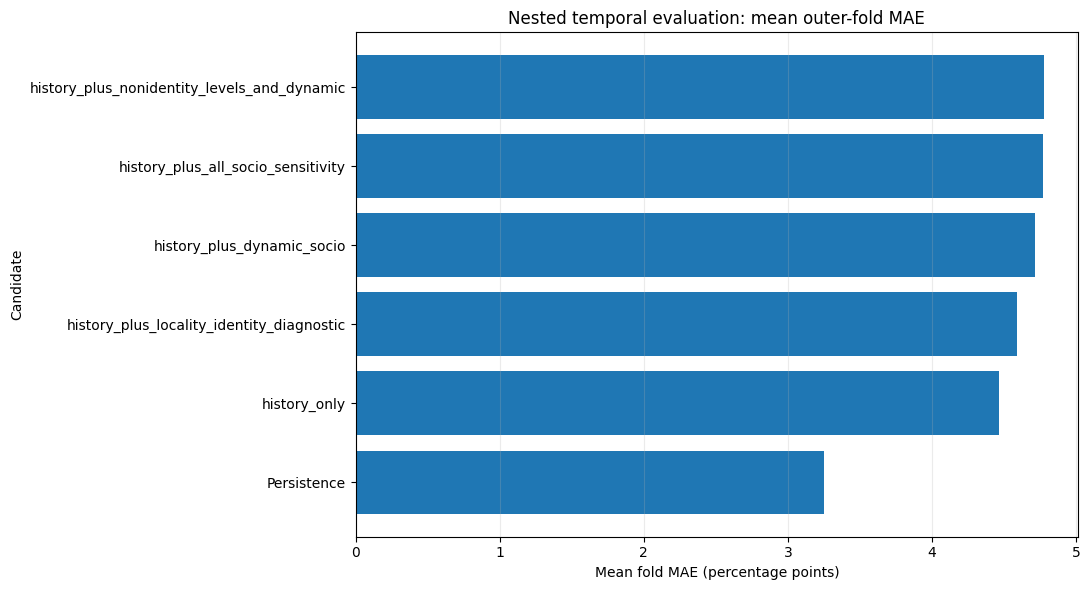

In [15]:
MEAN_FOLD_MAE_FIGURE = (
    FIGURES_DIR
    / "notebook_05_mean_fold_mae.png"
)

plot_summary = (
    aggregate_model_summary
    .assign(
        candidate_label=lambda frame: np.where(
            frame["model"].eq("Persistence"),
            "Persistence",
            frame["feature_set"],
        )
    )
    .sort_values(
        "mean_fold_mae",
        ascending=True,
    )
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

axis.barh(
    plot_summary["candidate_label"],
    plot_summary["mean_fold_mae"],
)

axis.set_title(
    "Nested temporal evaluation: mean outer-fold MAE"
)

axis.set_xlabel(
    "Mean fold MAE (percentage points)"
)

axis.set_ylabel("Candidate")

axis.grid(
    axis="x",
    alpha=0.25,
)

figure.tight_layout()

figure.savefig(
    MEAN_FOLD_MAE_FIGURE,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

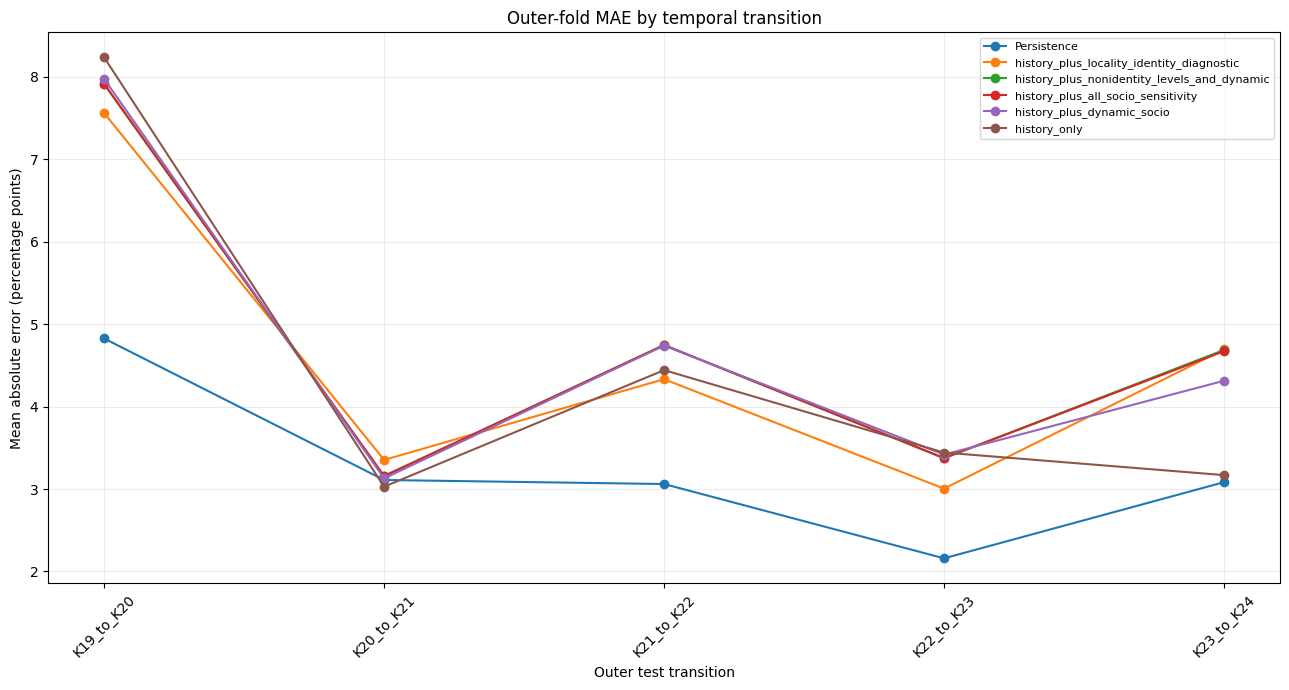

In [16]:
FOLD_MAE_FIGURE = (
    FIGURES_DIR
    / "notebook_05_mae_by_outer_fold.png"
)

figure, axis = plt.subplots(
    figsize=(13, 7)
)

for (
    model_name,
    feature_set_name,
), group in outer_fold_metrics.groupby(
    [
        "model",
        "feature_set",
    ],
    sort=False,
):
    group = group.sort_values(
        "transition_order"
    )

    label = (
        "Persistence"
        if model_name == "Persistence"
        else feature_set_name
    )

    axis.plot(
        group["transition_id"],
        group["overall_mae"],
        marker="o",
        label=label,
    )

axis.set_title(
    "Outer-fold MAE by temporal transition"
)

axis.set_xlabel("Outer test transition")

axis.set_ylabel(
    "Mean absolute error (percentage points)"
)

axis.tick_params(
    axis="x",
    rotation=45,
)

axis.grid(alpha=0.25)

axis.legend(
    fontsize=8,
)

figure.tight_layout()

figure.savefig(
    FOLD_MAE_FIGURE,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

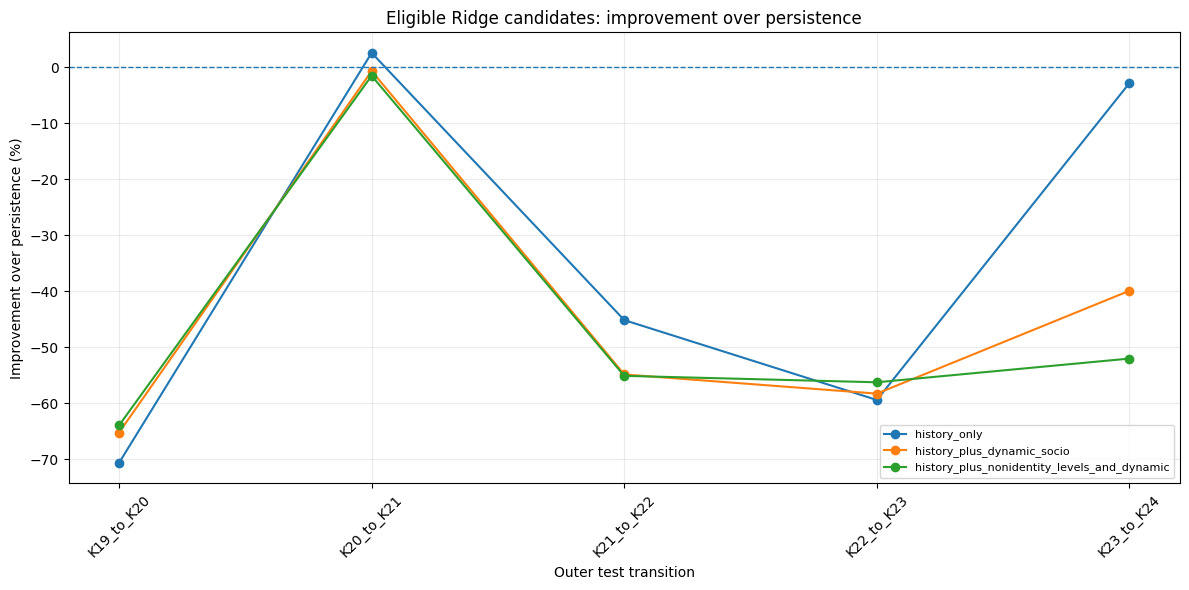

In [17]:
IMPROVEMENT_FIGURE = (
    FIGURES_DIR
    / "notebook_05_improvement_vs_persistence.png"
)

eligible_comparison = (
    outer_fold_comparison.loc[
        outer_fold_comparison["feature_set"]
        .isin(ELIGIBLE_FEATURE_SETS)
    ]
)

improvement_pivot = (
    eligible_comparison
    .pivot(
        index="transition_id",
        columns="feature_set",
        values="improvement_vs_persistence_pct",
    )
    .reindex(outer_test_transitions)
)

figure, axis = plt.subplots(
    figsize=(12, 6)
)

for feature_set_name in improvement_pivot.columns:
    axis.plot(
        improvement_pivot.index,
        improvement_pivot[
            feature_set_name
        ],
        marker="o",
        label=feature_set_name,
    )

axis.axhline(
    0,
    linestyle="--",
    linewidth=1,
)

axis.set_title(
    "Eligible Ridge candidates: improvement over persistence"
)

axis.set_xlabel("Outer test transition")

axis.set_ylabel(
    "Improvement over persistence (%)"
)

axis.tick_params(
    axis="x",
    rotation=45,
)

axis.grid(alpha=0.25)

axis.legend(fontsize=8)

figure.tight_layout()

figure.savefig(
    IMPROVEMENT_FIGURE,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

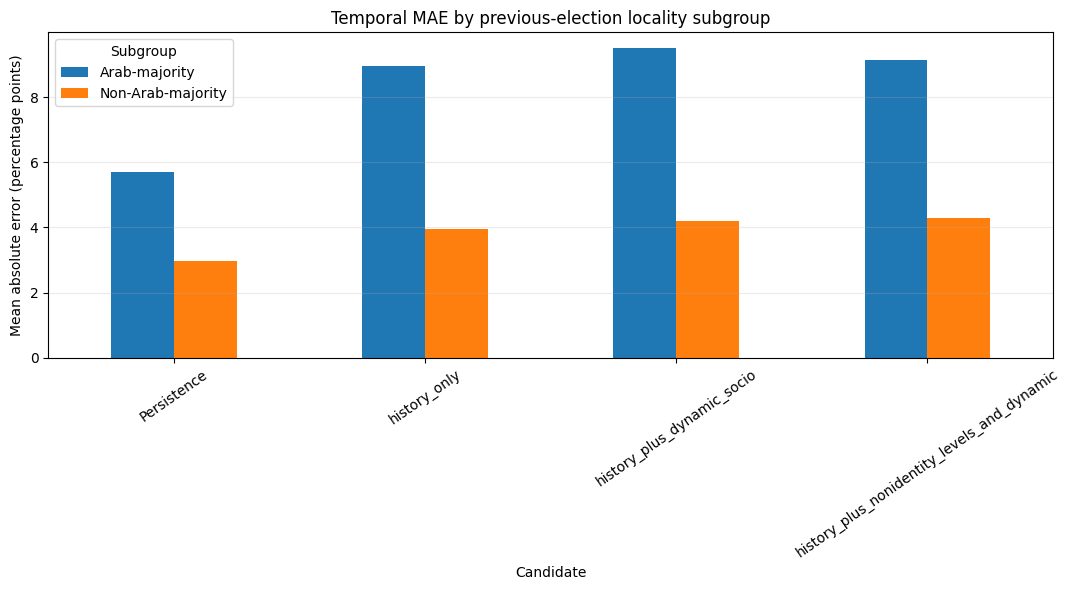

In [18]:
SUBGROUP_FIGURE = (
    FIGURES_DIR
    / "notebook_05_subgroup_mae.png"
)

subgroup_plot = (
    subgroup_metrics.loc[
        (
            subgroup_metrics["model"]
            .eq("Persistence")
        )
        | (
            subgroup_metrics["feature_set"]
            .isin(ELIGIBLE_FEATURE_SETS)
        )
    ]
    .copy()
)

subgroup_plot["candidate_label"] = np.where(
    subgroup_plot["model"].eq("Persistence"),
    "Persistence",
    subgroup_plot["feature_set"],
)

subgroup_pivot = subgroup_plot.pivot(
    index="candidate_label",
    columns="subgroup",
    values="overall_mae",
)

figure, axis = plt.subplots(
    figsize=(11, 6)
)

subgroup_pivot.plot(
    kind="bar",
    ax=axis,
)

axis.set_title(
    "Temporal MAE by previous-election locality subgroup"
)

axis.set_xlabel("Candidate")

axis.set_ylabel(
    "Mean absolute error (percentage points)"
)

axis.tick_params(
    axis="x",
    rotation=35,
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend(title="Subgroup")

figure.tight_layout()

figure.savefig(
    SUBGROUP_FIGURE,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## 15. Quality checks and leakage audit

In [19]:
quality_rows = []


def record_check(
    check,
    passed,
    value,
    requirement,
):
    quality_rows.append({
        "check": check,
        "passed": bool(passed),
        "value": value,
        "requirement": requirement,
    })


record_check(
    "all_notebook_04_checks_passed",
    bool(nb04_quality["passed"].all()),
    int(nb04_quality["passed"].sum()),
    len(nb04_quality),
)

record_check(
    "all_nine_transitions_present",
    actual_transitions == EXPECTED_TRANSITIONS,
    str(actual_transitions),
    str(EXPECTED_TRANSITIONS),
)

record_check(
    "only_k24_to_k25_is_locked",
    locked_transitions == [
        FINAL_TEST_TRANSITION
    ],
    str(locked_transitions),
    str([FINAL_TEST_TRANSITION]),
)

prediction_transitions = sorted(
    development_predictions[
        "transition_id"
    ]
    .drop_duplicates()
    .tolist()
)

record_check(
    "final_test_absent_from_predictions",
    FINAL_TEST_TRANSITION
    not in prediction_transitions,
    prediction_transitions,
    (
        f"{FINAL_TEST_TRANSITION} "
        "must be absent"
    ),
)

record_check(
    "five_outer_temporal_folds_created",
    len(outer_test_transitions) == 5,
    len(outer_test_transitions),
    5,
)

record_check(
    "every_outer_fold_has_three_or_more_training_transitions",
    bool(
        outer_fold_definitions[
            "number_of_training_transitions"
        ]
        .ge(
            MINIMUM_OUTER_TRAIN_TRANSITIONS
        )
        .all()
    ),
    int(
        outer_fold_definitions[
            "number_of_training_transitions"
        ].min()
    ),
    (
        f">= "
        f"{MINIMUM_OUTER_TRAIN_TRANSITIONS}"
    ),
)

temporal_order_valid = True

for row in outer_fold_definitions.itertuples(
    index=False
):
    test_position = (
        DEVELOPMENT_TRANSITIONS.index(
            row.outer_test_transition
        )
    )

    training_transitions = (
        row.training_transitions.split("|")
    )

    if any(
        DEVELOPMENT_TRANSITIONS.index(
            transition
        )
        >= test_position
        for transition in training_transitions
    ):
        temporal_order_valid = False
        break

record_check(
    "outer_training_transitions_precede_test_transition",
    temporal_order_valid,
    temporal_order_valid,
    True,
)

expected_candidates_per_fold = (
    1 + len(EXPECTED_FEATURE_SETS)
)

candidate_counts_by_fold = (
    development_predictions
    .groupby("transition_id")
    [
        [
            "model",
            "feature_set",
        ]
    ]
    .apply(
        lambda frame: int(
            frame.drop_duplicates().shape[0]
        )
    )
)

record_check(
    "every_outer_fold_contains_all_candidates",
    bool(
        candidate_counts_by_fold
        .eq(
            expected_candidates_per_fold
        )
        .all()
    ),
    candidate_counts_by_fold.to_dict(),
    expected_candidates_per_fold,
)

predicted_share_columns = [
    f"predicted_{bloc}_pct"
    for bloc in MODELED_BLOCS
]

missing_prediction_values = int(
    development_predictions[
        predicted_share_columns
    ]
    .isna()
    .sum()
    .sum()
)

record_check(
    "no_missing_predictions",
    missing_prediction_values == 0,
    missing_prediction_values,
    0,
)

maximum_prediction_sum_error = float(
    development_predictions[
        predicted_share_columns
    ]
    .sum(axis=1)
    .sub(100)
    .abs()
    .max()
)

record_check(
    "all_predictions_sum_to_100",
    maximum_prediction_sum_error
    <= 1e-8,
    maximum_prediction_sum_error,
    "<= 1e-8",
)

minimum_prediction = float(
    development_predictions[
        predicted_share_columns
    ]
    .min()
    .min()
)

maximum_prediction = float(
    development_predictions[
        predicted_share_columns
    ]
    .max()
    .max()
)

record_check(
    "all_predictions_are_between_0_and_100",
    (
        minimum_prediction >= -1e-10
        and maximum_prediction
        <= 100 + 1e-10
    ),
    (
        f"min={minimum_prediction}, "
        f"max={maximum_prediction}"
    ),
    "0 <= prediction <= 100",
)

persistence_check = (
    development_predictions.loc[
        development_predictions["model"]
        .eq("Persistence")
    ]
    .merge(
        development_data[
            [
                "row_id",
                *PREVIOUS_SHARE_COLUMNS,
            ]
        ],
        on="row_id",
        how="left",
        validate="one_to_one",
    )
)

persistence_max_difference = max(
    float(
        (
            persistence_check[
                f"predicted_{bloc}_pct"
            ]
            - persistence_check[
                f"previous_{bloc}_pct"
            ]
        )
        .abs()
        .max()
    )
    for bloc in MODELED_BLOCS
)

record_check(
    "persistence_equals_previous_shares",
    persistence_max_difference
    <= 1e-12,
    persistence_max_difference,
    "<= 1e-12",
)

persistence_metric_difference = abs(
    persistence_mean_fold_mae
    - NOTEBOOK_03_PERSISTENCE_MEAN_FOLD_MAE
)

record_check(
    "persistence_reproduces_notebook_03",
    persistence_metric_difference
    <= 1e-10,
    persistence_metric_difference,
    "<= 1e-10",
)

forbidden_exact_features = {
    "row_id",
    "locality_symbol",
    "locality_name",
    "current_valid_votes",
    "current_year",
    "current_election_number",
}

forbidden_prefixes = (
    "current_",
    "target_",
    "delta_",
)

contract_leakage_features = sorted({
    feature
    for feature in all_contract_features
    if (
        feature in forbidden_exact_features
        or feature.startswith(
            forbidden_prefixes
        )
    )
})

record_check(
    "feature_contract_contains_no_target_or_current_outcome_columns",
    not contract_leakage_features,
    contract_leakage_features,
    "[]",
)

record_check(
    "all_hyperparameter_searches_use_inner_folds",
    bool(
        hyperparameter_search[
            "inner_fold_count"
        ]
        .ge(1)
        .all()
    ),
    int(
        hyperparameter_search[
            "inner_fold_count"
        ].min()
    ),
    ">= 1",
)

record_check(
    "selection_uses_only_eligible_feature_sets",
    (
        best_ridge_feature_set
        in ELIGIBLE_FEATURE_SETS
    ),
    best_ridge_feature_set,
    str(ELIGIBLE_FEATURE_SETS),
)

record_check(
    "locked_final_test_rows_remain_available_but_untouched",
    len(final_test_data) > 0,
    len(final_test_data),
    "> 0",
)

record_check(
    "research_bundle_is_development_only",
    research_challenger_bundle[
        "training_transitions"
    ]
    == DEVELOPMENT_TRANSITIONS,
    str(
        research_challenger_bundle[
            "training_transitions"
        ]
    ),
    str(DEVELOPMENT_TRANSITIONS),
)

notebook_05_quality_checks = pd.DataFrame(
    quality_rows
)

display(notebook_05_quality_checks)

failed_checks = notebook_05_quality_checks.loc[
    ~notebook_05_quality_checks["passed"]
]

if not failed_checks.empty:
    raise RuntimeError(
        "Notebook 05 quality checks failed:\n"
        + failed_checks.to_string(
            index=False
        )
    )

print(
    "All Notebook 05 quality checks passed."
)

,check,passed,value,requirement
0,all_notebook_04_checks_passed,True,15,15
1,all_nine_transitions_present,True,"['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1...","['K16_to_K17', 'K17_to_K18', 'K18_to_K19', 'K1..."
2,only_k24_to_k25_is_locked,True,['K24_to_K25'],['K24_to_K25']
3,final_test_absent_from_predictions,True,"[K19_to_K20, K20_to_K21, K21_to_K22, K22_to_K2...",K24_to_K25 must be absent
4,five_outer_temporal_folds_created,True,5,5
5,every_outer_fold_has_three_or_more_training_tr...,True,3,>= 3
6,outer_training_transitions_precede_test_transi...,True,True,True
7,every_outer_fold_contains_all_candidates,True,"{'K19_to_K20': 6, 'K20_to_K21': 6, 'K21_to_K22...",6
8,no_missing_predictions,True,0,0
9,all_predictions_sum_to_100,True,0.0,<= 1e-8


All Notebook 05 quality checks passed.


## 16. Save Notebook 05 outputs

In [20]:
OUTER_FOLD_DEFINITIONS_PATH = (
    TABLES_DIR
    / "notebook_05_outer_fold_definitions.csv"
)

HYPERPARAMETER_SEARCH_PATH = (
    TABLES_DIR
    / "notebook_05_hyperparameter_search.csv"
)

SELECTED_HYPERPARAMETERS_PATH = (
    TABLES_DIR
    / "notebook_05_selected_hyperparameters.csv"
)

DEVELOPMENT_PREDICTIONS_PATH = (
    TABLES_DIR
    / "notebook_05_development_predictions.csv"
)

OUTER_FOLD_METRICS_PATH = (
    TABLES_DIR
    / "notebook_05_outer_fold_metrics.csv"
)

OUTER_FOLD_COMPARISON_PATH = (
    TABLES_DIR
    / "notebook_05_outer_fold_comparison.csv"
)

AGGREGATE_SUMMARY_PATH = (
    TABLES_DIR
    / "notebook_05_aggregate_model_summary.csv"
)

SUBGROUP_METRICS_PATH = (
    TABLES_DIR
    / "notebook_05_subgroup_metrics.csv"
)

SIZE_BAND_METRICS_PATH = (
    TABLES_DIR
    / "notebook_05_size_band_metrics.csv"
)

BOOTSTRAP_COMPARISONS_PATH = (
    TABLES_DIR
    / "notebook_05_bootstrap_comparisons.csv"
)

INCREMENTAL_COMPARISONS_PATH = (
    TABLES_DIR
    / "notebook_05_incremental_comparisons.csv"
)

COEFFICIENT_SUMMARY_PATH = (
    TABLES_DIR
    / "notebook_05_coefficient_summary.csv"
)

QUALITY_CHECKS_PATH = (
    TABLES_DIR
    / "notebook_05_quality_checks.csv"
)

MODEL_DECISION_PATH = (
    SUMMARIES_DIR
    / "notebook_05_model_decision.json"
)

NOTEBOOK_SUMMARY_PATH = (
    SUMMARIES_DIR
    / "notebook_05_summary.json"
)

outer_fold_definitions.to_csv(
    OUTER_FOLD_DEFINITIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

hyperparameter_search.to_csv(
    HYPERPARAMETER_SEARCH_PATH,
    index=False,
    encoding="utf-8-sig",
)

selected_hyperparameters.to_csv(
    SELECTED_HYPERPARAMETERS_PATH,
    index=False,
    encoding="utf-8-sig",
)

development_predictions.to_csv(
    DEVELOPMENT_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

outer_fold_metrics.to_csv(
    OUTER_FOLD_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

outer_fold_comparison.to_csv(
    OUTER_FOLD_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

aggregate_model_summary.to_csv(
    AGGREGATE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

subgroup_metrics.to_csv(
    SUBGROUP_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

size_band_metrics.to_csv(
    SIZE_BAND_METRICS_PATH,
    index=False,
    encoding="utf-8-sig",
)

bootstrap_comparisons.to_csv(
    BOOTSTRAP_COMPARISONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

incremental_comparisons.to_csv(
    INCREMENTAL_COMPARISONS_PATH,
    index=False,
    encoding="utf-8-sig",
)

coefficient_summary.to_csv(
    COEFFICIENT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

notebook_05_quality_checks.to_csv(
    QUALITY_CHECKS_PATH,
    index=False,
    encoding="utf-8-sig",
)

MODEL_DECISION_PATH.write_text(
    json.dumps(
        model_decision,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

notebook_summary = {
    "notebook": "05_delta_modeling",
    "version": (
        "nested_temporal_clr_delta_ridge"
    ),
    "created_at_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),
    "git_commit": GIT_COMMIT,
    "development_transitions": (
        DEVELOPMENT_TRANSITIONS
    ),
    "outer_test_transitions": (
        outer_test_transitions
    ),
    "final_test_transition": (
        FINAL_TEST_TRANSITION
    ),
    "final_test_locked": True,
    "final_test_used": False,
    "target": "four_bloc_delta_clr",
    "outer_evaluation": (
        "rolling_temporal_validation"
    ),
    "hyperparameter_selection": (
        "nested_rolling_temporal_validation"
    ),
    "alpha_grid": ALPHA_GRID,
    "shrinkage_grid": SHRINKAGE_GRID,
    "eligible_feature_sets": (
        ELIGIBLE_FEATURE_SETS
    ),
    "sensitivity_feature_sets": (
        SENSITIVITY_FEATURE_SETS
    ),
    "primary_challenger": (
        PRIMARY_CHALLENGER
    ),
    "persistence_mean_fold_mae": (
        persistence_mean_fold_mae
    ),
    "best_eligible_ridge_feature_set": (
        best_ridge_feature_set
    ),
    "best_eligible_ridge_mean_fold_mae": (
        best_ridge_mean_fold_mae
    ),
    "frozen_temporal_winner": (
        frozen_temporal_winner
    ),
    "temporal_challenger_passed": (
        temporal_challenger_passed
    ),
    "primary_dynamic_beats_persistence": (
        dynamic_beats_persistence
    ),
    "primary_dynamic_adds_beyond_history": (
        dynamic_adds_beyond_history
    ),
    "notebook_06_policy": (
        notebook_06_policy
    ),
    "research_bundle_feature_set": (
        best_ridge_feature_set
    ),
    "research_bundle_alpha": (
        full_alpha
    ),
    "research_bundle_shrinkage": (
        full_shrinkage
    ),
    "quality_checks_passed": bool(
        notebook_05_quality_checks[
            "passed"
        ].all()
    ),
    "outputs": {
        "outer_fold_definitions": str(
            OUTER_FOLD_DEFINITIONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "hyperparameter_search": str(
            HYPERPARAMETER_SEARCH_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "selected_hyperparameters": str(
            SELECTED_HYPERPARAMETERS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "development_predictions": str(
            DEVELOPMENT_PREDICTIONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "outer_fold_metrics": str(
            OUTER_FOLD_METRICS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "outer_fold_comparison": str(
            OUTER_FOLD_COMPARISON_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "aggregate_summary": str(
            AGGREGATE_SUMMARY_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "subgroup_metrics": str(
            SUBGROUP_METRICS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "size_band_metrics": str(
            SIZE_BAND_METRICS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "bootstrap_comparisons": str(
            BOOTSTRAP_COMPARISONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "incremental_comparisons": str(
            INCREMENTAL_COMPARISONS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "coefficient_summary": str(
            COEFFICIENT_SUMMARY_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "quality_checks": str(
            QUALITY_CHECKS_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "model_decision": str(
            MODEL_DECISION_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "research_challenger_bundle": str(
            RESEARCH_CHALLENGER_BUNDLE_PATH.relative_to(
                REPO_ROOT
            )
        ),
        "mean_fold_mae_figure": str(
            MEAN_FOLD_MAE_FIGURE.relative_to(
                REPO_ROOT
            )
        ),
        "fold_mae_figure": str(
            FOLD_MAE_FIGURE.relative_to(
                REPO_ROOT
            )
        ),
        "improvement_figure": str(
            IMPROVEMENT_FIGURE.relative_to(
                REPO_ROOT
            )
        ),
        "subgroup_figure": str(
            SUBGROUP_FIGURE.relative_to(
                REPO_ROOT
            )
        ),
    },
}

NOTEBOOK_SUMMARY_PATH.write_text(
    json.dumps(
        notebook_summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

OUTPUT_PATHS = [
    OUTER_FOLD_DEFINITIONS_PATH,
    HYPERPARAMETER_SEARCH_PATH,
    SELECTED_HYPERPARAMETERS_PATH,
    DEVELOPMENT_PREDICTIONS_PATH,
    OUTER_FOLD_METRICS_PATH,
    OUTER_FOLD_COMPARISON_PATH,
    AGGREGATE_SUMMARY_PATH,
    SUBGROUP_METRICS_PATH,
    SIZE_BAND_METRICS_PATH,
    BOOTSTRAP_COMPARISONS_PATH,
    INCREMENTAL_COMPARISONS_PATH,
    COEFFICIENT_SUMMARY_PATH,
    QUALITY_CHECKS_PATH,
    MODEL_DECISION_PATH,
    NOTEBOOK_SUMMARY_PATH,
    RESEARCH_CHALLENGER_BUNDLE_PATH,
    MEAN_FOLD_MAE_FIGURE,
    FOLD_MAE_FIGURE,
    IMPROVEMENT_FIGURE,
    SUBGROUP_FIGURE,
]

output_audit = pd.DataFrame([
    {
        "relative_path": str(
            path.relative_to(REPO_ROOT)
        ),
        "exists": path.exists(),
        "size_bytes": (
            path.stat().st_size
            if path.exists()
            else 0
        ),
    }
    for path in OUTPUT_PATHS
])

display(output_audit)

bad_outputs = output_audit.loc[
    ~output_audit["exists"]
    | output_audit["size_bytes"].le(0)
]

if not bad_outputs.empty:
    raise RuntimeError(
        "Missing or empty Notebook 05 outputs:\n"
        + bad_outputs.to_string(
            index=False
        )
    )

print(
    "All Notebook 05 outputs were saved successfully."
)

,relative_path,exists,size_bytes
0,reports/tables/notebook_05_outer_fold_definiti...,True,518
1,reports/tables/notebook_05_hyperparameter_sear...,True,36462
2,reports/tables/notebook_05_selected_hyperparam...,True,3526
3,reports/tables/notebook_05_development_predict...,True,18360627
4,reports/tables/notebook_05_outer_fold_metrics.csv,True,6766
5,reports/tables/notebook_05_outer_fold_comparis...,True,8391
6,reports/tables/notebook_05_aggregate_model_sum...,True,2413
7,reports/tables/notebook_05_subgroup_metrics.csv,True,2794
8,reports/tables/notebook_05_size_band_metrics.csv,True,5301
9,reports/tables/notebook_05_bootstrap_compariso...,True,1078


All Notebook 05 outputs were saved successfully.


## 17. Download all Notebook 05 outputs

In [21]:
# Independent download cell: it uses explicit paths and does not depend on
# the OUTPUT_PATHS variable remaining in memory.
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files

repo_root = Path(
    "/content/Election_Bloc_Prediction_Project_nb05"
)

zip_path = Path(
    "/content/notebook_05_outputs.zip"
)

output_files = [
    repo_root
    / "reports/tables/notebook_05_outer_fold_definitions.csv",
    repo_root
    / "reports/tables/notebook_05_hyperparameter_search.csv",
    repo_root
    / "reports/tables/notebook_05_selected_hyperparameters.csv",
    repo_root
    / "reports/tables/notebook_05_development_predictions.csv",
    repo_root
    / "reports/tables/notebook_05_outer_fold_metrics.csv",
    repo_root
    / "reports/tables/notebook_05_outer_fold_comparison.csv",
    repo_root
    / "reports/tables/notebook_05_aggregate_model_summary.csv",
    repo_root
    / "reports/tables/notebook_05_subgroup_metrics.csv",
    repo_root
    / "reports/tables/notebook_05_size_band_metrics.csv",
    repo_root
    / "reports/tables/notebook_05_bootstrap_comparisons.csv",
    repo_root
    / "reports/tables/notebook_05_incremental_comparisons.csv",
    repo_root
    / "reports/tables/notebook_05_coefficient_summary.csv",
    repo_root
    / "reports/tables/notebook_05_quality_checks.csv",
    repo_root
    / "reports/summaries/notebook_05_model_decision.json",
    repo_root
    / "reports/summaries/notebook_05_summary.json",
    repo_root
    / "models/notebook_05_research_challenger_bundle.joblib",
    repo_root
    / "reports/figures/notebook_05_mean_fold_mae.png",
    repo_root
    / "reports/figures/notebook_05_mae_by_outer_fold.png",
    repo_root
    / "reports/figures/notebook_05_improvement_vs_persistence.png",
    repo_root
    / "reports/figures/notebook_05_subgroup_mae.png",
]

missing_files = [
    str(path.relative_to(repo_root))
    for path in output_files
    if (
        not path.exists()
        or path.stat().st_size <= 0
    )
]

if missing_files:
    raise RuntimeError(
        "Run the Notebook 05 save cell first. "
        "Missing outputs:\n- "
        + "\n- ".join(missing_files)
    )

if zip_path.exists():
    zip_path.unlink()

with ZipFile(
    zip_path,
    mode="w",
    compression=ZIP_DEFLATED,
) as zip_file:
    for path in output_files:
        zip_file.write(
            path,
            arcname=str(
                path.relative_to(repo_root)
            ),
        )

print("ZIP created:", zip_path)
print(
    "ZIP size:",
    zip_path.stat().st_size,
    "bytes",
)
print(
    "Files included:",
    len(output_files),
)

files.download(str(zip_path))

ZIP created: /content/notebook_05_outputs.zip
ZIP size: 5897444 bytes
Files included: 20


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Completion criteria

A successful run ends with:

```text
Earlier-notebook validation passed.
Model-table validation passed.
All Notebook 05 quality checks passed.
All Notebook 05 outputs were saved successfully.
ZIP created: /content/notebook_05_outputs.zip
```

The notebook must never contain `K24_to_K25` in:

- development predictions;
- outer-fold metrics;
- hyperparameter selection folds;
- candidate-selection calculations.

Notebook 06 should read:

- `reports/summaries/notebook_05_model_decision.json`
- `reports/summaries/notebook_05_summary.json`
- `reports/tables/notebook_05_aggregate_model_summary.csv`
- `models/notebook_05_research_challenger_bundle.joblib`

and then evaluate unseen-locality generalization using grouped splits.